# IaCGOD Retriever Agent — Hybrid RAG Retrieval Simulation

This notebook drives the **actual** retrieval pipeline implemented in
`agents/retriever.py` against a **live** ChromaDB + Neo4j knowledge base, using the
**Ollama** embedding model (`mxbai-embed-large`, via `tools/embedding_provider.py`) —
exactly as the Retriever agent does inside IaCGOD's LangGraph state machine.

Nothing here is a re-implementation or a mock of the retrieval logic. Every retrieval
call below goes through the real, unmodified functions:

- `tools.cfn_hybrid_rag.execute_hybrid_retrieval` (ChromaDB semantic search → Neo4j
  schema traversal)
- `tools.security_hybrid_rag.execute_security_retrieval` (Neo4j-only security lookup)
- `agents.retriever.retriever_agent` itself, called unmodified in the final section

## What gets simulated

| # | Query type | What triggers it | Path the real agent takes |
|---|---|---|---|
| 1 | **Lint error query** (cfn-lint) | `has_schema=True` | LLM query-gen → **ChromaDB** semantic search (Ollama embeddings) → **Neo4j** `Resource` schema traversal |
| 2 | **Trivy error query** (security) | `has_security=True` | Deterministic regex ID extraction (no LLM, no embeddings) → **Neo4j** `SecurityCheck` traversal only |
| 3 | **Deploy error query** | `has_schema=True` (a deploy failure) | Same path as (1), but Neo4j is scoped to only the resource(s) named in `failed_resources` |

**Important fidelity note.** The retriever agent deliberately does **not** run a
ChromaDB semantic search for Trivy/Checkov findings. `tools/security_hybrid_rag.py`'s
own module docstring explains why: the validator already emits an explicit rule ID
(e.g. `AVD-AWS-0086`), so there is no ambiguity for a vector search to resolve —
"ChromaDB semantic search has been removed because Trivy/Checkov validators always
emit explicit rule IDs." Forcing an embedding lookup into the Trivy path here would
misrepresent what the shipped agent actually does, so this notebook reproduces that
asymmetry rather than "fixing" it. Likewise, "deploy error query" is not a separate
code path in the real agent — a deploy failure is folded into the same structural
(`has_schema`) errors list and drives the same ChromaDB+Neo4j pipeline as a lint error,
just scoped to a different resource set. Both distinctions are demonstrated explicitly
below rather than glossed over.

## Prerequisites (start these before running)

1. **Neo4j** at `bolt://localhost:7687`, already populated by
   `scripts/graphrag/04_import_cfn_to_neo4j.py` (CFN schema graph),
   `scripts/graphrag/terraform/04_import_tf_to_neo4j.py` (Terraform schema
   graph — required for the TF section added below), and
   `scripts/graphrag/security/04_import_security_to_neo4j.py` (security graph).
2. **ChromaDB** server at `localhost:8000` (`chroma run --path <dir>`), already
   populated by `scripts/graphrag/05_build_chromadb.py` into the
   `cfn_schema_properties` collection, and (for the TF section)
   `scripts/graphrag/terraform/05_build_tf_chromadb.py` into `tf_schema_properties`.
3. **Ollama** at `localhost:11434` with the embedding model pulled:
   `ollama pull mxbai-embed-large`.
4. `EMBEDDING_PROVIDER=ollama` (set below) — this **must** match whatever provider
   built the ChromaDB collection, or cosine-distance scores are meaningless
   (see `tools/embedding_provider.py`'s own "Index / query model parity" warning).
5. *(Optional, for the real LLM query-generation call)* `OPENROUTER_API_KEY` in
   `.env` — already present in this repo. Without it, this notebook falls back to
   the exact same fallback the real agent uses when the LLM call fails:
   `schema_queries = errors[:8]`.

Run this notebook from the **IaCGOD repo root** — it imports `agents/`, `tools/`,
`prompts/`, `state.py`, `tracking/` as top-level packages, exactly like `main.py`
does.

In [3]:
import os, sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "agents" / "retriever.py").exists():
    raise RuntimeError(
        "Run this notebook from the IaCGOD repo root (it imports agents/, tools/, "
        "prompts/, state.py, tracking/ as top-level packages, exactly like main.py)."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Force the SAME embedding provider/model the retriever agent uses in production.
# Must be set BEFORE importing tools.embedding_provider — it reads these via a
# module-level os.getenv() at import time (see tools/embedding_provider.py).
os.environ.setdefault("EMBEDDING_PROVIDER", "ollama")
os.environ.setdefault("EMBEDDING_MODEL", "mxbai-embed-large")
os.environ.setdefault("OLLAMA_BASE_URL", "http://localhost:11434")
os.environ.setdefault("NEO4J_URI", "bolt://localhost:7687")
os.environ.setdefault("NEO4J_USER", "neo4j")
os.environ.setdefault("NEO4J_PASSWORD", "password")
os.environ.setdefault("CHROMA_HOST", "localhost")
os.environ.setdefault("CHROMA_PORT", "8000")

import json
import logging
import textwrap
from collections import Counter

import chromadb
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from neo4j import GraphDatabase

# This environment's networkx (2.6.3) predates NumPy 2.0 and still calls the
# `np.alltrue` alias internally inside draw_networkx_edges() for certain
# node_color list shapes; NumPy 2.x removed it outright. `alltrue` was always a
# pure alias for `all`, so restoring it is a safe, in-process-only shim (no
# site-packages changes) rather than a behavioural workaround.
if not hasattr(np, "alltrue"):
    np.alltrue = np.all

# The Neo4j driver logs a "Received notification from DBMS server" line for every
# informational GQL notification (e.g. an OPTIONAL MATCH on a relationship type
# that doesn't exist yet in this particular graph build) — harmless, but noisy in
# a notebook. Silencing it doesn't hide real errors: driver exceptions still raise
# normally and are still caught by the try/except blocks below.
logging.getLogger("neo4j").setLevel(logging.ERROR)

# config.py calls load_dotenv() as an import side effect, populating
# OPENROUTER_API_KEY etc. from .env — importing it mirrors main.py's own
# bootstrap order, so agents.llm_client sees the same credentials it would in
# a real run.
import config  # noqa: F401

from tools.embedding_provider import get_embeddings, get_provider, get_model_name
from tools import validators
from tools import template_annotator as ta
from tools.retriever_helpers import extract_errors, parse_query_response, format_deploy_errors
from tools import cfn_hybrid_rag as rag
from tools import security_hybrid_rag as secrag
from prompts.retriever_prompt import get_query_gen_system
from agents.retriever import (
    retriever_agent,
    build_retrieval_prompt,
    _get_active_error_types,
    _extract_error_resources,
    _annotate_safely,
    _call_query_generator,
    _build_retrieval_annotated_template,
)
from tracking.recorder import ResearchRecorder

print(f"[Embeddings] provider={get_provider()!r}  model={get_model_name()!r}")
print(f"[Neo4j]      {os.environ['NEO4J_URI']}")
print(f"[ChromaDB]   http://{os.environ['CHROMA_HOST']}:{os.environ['CHROMA_PORT']}")

[Embeddings] provider='ollama'  model='mxbai-embed-large'
[Neo4j]      bolt://localhost:7687
[ChromaDB]   http://localhost:8000


## 0 · Connectivity check

Verifies the three backing services the retriever depends on, and reports the exact
node/edge counts currently sitting in Neo4j — this doubles as a sanity check that the
`04_import_cfn_to_neo4j.py` / `04_import_security_to_neo4j.py` build scripts have
actually been run.

In [4]:
def check_ollama():
    import urllib.request
    try:
        with urllib.request.urlopen(
            f"{os.environ['OLLAMA_BASE_URL']}/api/tags", timeout=5
        ) as r:
            tags = json.loads(r.read())
        names = [m["name"] for m in tags.get("models", [])]
        target = os.environ["EMBEDDING_MODEL"]
        hit = any(n.split(":")[0] == target for n in names)
        return hit, names
    except Exception as exc:
        return None, str(exc)


def check_chroma():
    try:
        client = chromadb.HttpClient(
            host=os.environ["CHROMA_HOST"], port=int(os.environ["CHROMA_PORT"])
        )
        cols = [c.name for c in client.list_collections()]
        counts = {name: client.get_collection(name).count() for name in cols}
        return True, {"collections": cols, "counts": counts}
    except Exception as exc:
        return False, str(exc)


def check_neo4j():
    try:
        driver = GraphDatabase.driver(
            os.environ["NEO4J_URI"],
            auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]),
        )
        with driver.session() as session:
            counts = {}
            for label in (
                "Resource", "Property", "NestedType", "Example",
                "SecurityCheck", "Impact", "Remediation", "GoodExample",
                "RegoPolicy", "AwsService",
            ):
                rec = session.run(f"MATCH (n:{label}) RETURN count(n) AS c").single()
                counts[label] = rec["c"] if rec else 0
        driver.close()
        return True, counts
    except Exception as exc:
        return False, str(exc)


ollama_ok, ollama_info = check_ollama()
chroma_ok, chroma_info = check_chroma()
neo4j_ok, neo4j_info = check_neo4j()

print("=== Ollama ===")
if ollama_ok is True:
    print(f"  '{os.environ['EMBEDDING_MODEL']}' available "
          f"(among {len(ollama_info)} local model(s)).")
elif ollama_ok is False:
    print(f"  UNREACHABLE-or-model-missing. Local models: {ollama_info}")
    print(f"  Run: ollama pull {os.environ['EMBEDDING_MODEL']}")
else:
    print(f"  UNREACHABLE: {ollama_info}")

print("\n=== ChromaDB ===")
print(f"  {chroma_info}" if chroma_ok else f"  UNREACHABLE: {chroma_info}")

print("\n=== Neo4j ===")
if neo4j_ok:
    for k, v in neo4j_info.items():
        print(f"  {k:<14} {v:>7,}")
else:
    print(f"  UNREACHABLE: {neo4j_info}")

ALL_UP = bool(ollama_ok) and chroma_ok and neo4j_ok
if not ALL_UP:
    print(
        "\n⚠ One or more backing services are unreachable. Cells below will "
        "still run — cfn_hybrid_rag.py and security_hybrid_rag.py wrap every DB "
        "call in try/except and degrade gracefully on failure, exactly like the "
        "real agent does — but you won't see real retrieved content until Ollama, "
        "ChromaDB, and Neo4j are all up and the knowledge graph is populated."
    )

=== Ollama ===
  'mxbai-embed-large' available (among 6 local model(s)).

=== ChromaDB ===
  {'collections': ['cfn_schema_properties', 'tf_schema_properties'], 'counts': {'cfn_schema_properties': 13999, 'tf_schema_properties': 66792}}

=== Neo4j ===
  Resource         1,862
  Property         7,433
  NestedType       6,523
  Example          2,170
  SecurityCheck      732
  Impact               0
  Remediation        241
  GoodExample        241
  RegoPolicy         175
  AwsService          82


## 1 · Sample IaC template + a failing validation state

A small CloudFormation template with three independent problems, one per query type
this notebook simulates:

1. A **cfn-lint** schema violation (an unexpected/misspelled property on the security
   group) — drives the **lint error query**.
2. A **Trivy** HIGH-severity misconfiguration (an ingress rule open to `0.0.0.0/0`) —
   drives the **Trivy error query**.
3. A **deploy failure** — a hardcoded, non-existent AMI ID on the EC2 instance. This
   is the exact "Category 5 — Greenfield missing dependency" failure class described
   in `prompts/retriever_prompt.py`'s query-generation system prompt. Since running an
   actual `CreateStack` against AWS/LocalStack is out of scope for a retrieval-only
   notebook, this one failure is constructed by hand (clearly marked) — but it is
   rendered through the real `format_deploy_errors()` helper so the error text the
   retriever sees is byte-for-byte what the production pipeline would produce.

cfn-lint and Trivy are invoked exactly as `tools/validators.py` invokes them
(`validate_cfn_lint`, `validate_trivy`) — the errors below are genuinely produced by
those tools running against the template, not hand-typed.

In [5]:
SAMPLE_TEMPLATE = textwrap.dedent("""
    AWSTemplateFormatVersion: "2010-09-09"
    Description: Demo web-tier stack with an intentional lint bug and an open ingress rule.

    Resources:
      WebServerSecurityGroup:
        Type: AWS::EC2::SecurityGroup
        Properties:
          GroupDescription: Allow web and SSH traffic
          SecurityGroupIngress:
            - IpProtcol: tcp
              FromPort: 22
              ToPort: 22
              CidrIp: 0.0.0.0/0
            - IpProtocol: tcp
              FromPort: 80
              ToPort: 80
              CidrIp: 0.0.0.0/0

      WebServerInstance:
        Type: AWS::EC2::Instance
        Properties:
          InstanceType: t3.micro
          ImageId: ami-00000000000000000
          SecurityGroupIds:
            - !GetAtt WebServerSecurityGroup.GroupId

    Outputs:
      InstancePublicIp:
        Value: !GetAtt WebServerInstance.PublicIp
""").strip() + "\n"

print(SAMPLE_TEMPLATE)

AWSTemplateFormatVersion: "2010-09-09"
Description: Demo web-tier stack with an intentional lint bug and an open ingress rule.

Resources:
  WebServerSecurityGroup:
    Type: AWS::EC2::SecurityGroup
    Properties:
      GroupDescription: Allow web and SSH traffic
      SecurityGroupIngress:
        - IpProtcol: tcp
          FromPort: 22
          ToPort: 22
          CidrIp: 0.0.0.0/0
        - IpProtocol: tcp
          FromPort: 80
          ToPort: 80
          CidrIp: 0.0.0.0/0

  WebServerInstance:
    Type: AWS::EC2::Instance
    Properties:
      InstanceType: t3.micro
      ImageId: ami-00000000000000000
      SecurityGroupIds:
        - !GetAtt WebServerSecurityGroup.GroupId

Outputs:
  InstancePublicIp:
    Value: !GetAtt WebServerInstance.PublicIp



In [6]:
# Run the REAL validators — same functions tools/validators.py exposes to the
# rest of the pipeline (validate_cfn_lint shells out to the cfn-lint binary,
# validate_trivy shells out to the trivy binary).
lint_result = validators.validate_cfn_lint(SAMPLE_TEMPLATE)
trivy_result = validators.validate_trivy(SAMPLE_TEMPLATE, iac_type="cloudformation")

print(f"[cfn-lint] passed={lint_result['passed']}  {len(lint_result['errors'])} error(s)")
for e in lint_result["errors"]:
    print(f"  - {e}")

print(f"\n[trivy]    passed={trivy_result['passed']}  {len(trivy_result['errors'])} error(s)")
for e in trivy_result["errors"]:
    print(f"  - {e}")

[cfn-lint] passed=False  2 error(s)
  - [E3002] | line 10 | Resource: WebServerSecurityGroup | Additional properties are not allowed ('IpProtcol' was unexpected. Did you mean 'IpProtocol'?) | Making sure that resources properties are properly configured
  - [E3003] | line 10 | Resource: WebServerSecurityGroup | 'IpProtocol' is a required property | Make sure that Resources properties that are required exist

[trivy]    passed=False  2 error(s)
  - [AWS-0028] HIGH: aws_instance should activate session tokens for Instance Metadata Service. — Instance does not require IMDS access to require a token.
  - [AWS-0131] HIGH: Instance with unencrypted block device. — Root block device is not encrypted.


In [7]:
# The deploy failure is constructed by hand (no real CreateStack call here — this
# notebook is about retrieval, not deployment) but rendered through the exact same
# format_deploy_errors() the real pipeline uses, so the text the retriever sees is
# identical in shape to a genuine deploy_validation_result.
deploy_validation_result = {
    "target": "aws",
    "passed": False,
    "stack_id": None,
    "completed_resources": ["WebServerSecurityGroup"],
    "failed_resources": [
        {
            "logical_name": "WebServerInstance",
            "status_reason": (
                "Resource creation cancelled: The image id 'ami-00000000000000000' "
                "does not exist"
            ),
        }
    ],
    "error_message": None,
    "duration_seconds": 42.7,
    "deployment_logs": [
        "CREATE_IN_PROGRESS  WebServerSecurityGroup",
        "CREATE_COMPLETE     WebServerSecurityGroup",
        "CREATE_IN_PROGRESS  WebServerInstance",
        "CREATE_FAILED       WebServerInstance  The image id 'ami-00000000000000000' does not exist",
        "ROLLBACK_IN_PROGRESS",
    ],
}

print(format_deploy_errors(deploy_validation_result))

**Target:** AWS
**Failed resources:**
  - `WebServerInstance`: Resource creation cancelled: The image id 'ami-00000000000000000' does not exist
**Completed successfully:** `WebServerSecurityGroup`
**Deployment event log (errors only):**
  - CREATE_FAILED       WebServerInstance  The image id 'ami-00000000000000000' does not exist


In [8]:
# Assemble the GraphState shape retriever_agent() actually reads (state.py's
# GraphState TypedDict) — validation_results is a list of ValidationResult dicts,
# exactly what tools/validators.py returns and what main.py's validation stage
# would append to state["validation_results"].
state = {
    "iac_type": "cloudformation",
    "iac_template": SAMPLE_TEMPLATE,
    "validation_results": [lint_result, trivy_result],
    "deploy_validation_result": deploy_validation_result,
    "smell_report": None,
    "remediation_history": [],
    "current_iteration": 1,
    "llm_call_log": [],
    "retriever_history": [],
}

# extract_errors() is the exact helper retriever_agent() calls first — it flattens
# every failed validation_results[*].errors plus, when present, a formatted
# deploy-failure block via format_deploy_errors().
errors = extract_errors(state["validation_results"], state["deploy_validation_result"])
print(f"{len(errors)} error string(s) extracted by extract_errors():\n")
for e in errors:
    print(f"- {e}\n")

5 error string(s) extracted by extract_errors():

- [E3002] | line 10 | Resource: WebServerSecurityGroup | Additional properties are not allowed ('IpProtcol' was unexpected. Did you mean 'IpProtocol'?) | Making sure that resources properties are properly configured

- [E3003] | line 10 | Resource: WebServerSecurityGroup | 'IpProtocol' is a required property | Make sure that Resources properties that are required exist

- [AWS-0028] HIGH: aws_instance should activate session tokens for Instance Metadata Service. — Instance does not require IMDS access to require a token.

- [AWS-0131] HIGH: Instance with unencrypted block device. — Root block device is not encrypted.

- **Target:** AWS
**Failed resources:**
  - `WebServerInstance`: Resource creation cancelled: The image id 'ami-00000000000000000' does not exist
**Completed successfully:** `WebServerSecurityGroup`
**Deployment event log (errors only):**
  - CREATE_FAILED       WebServerInstance  The image id 'ami-00000000000000000' does 

## 2 · Routing decision — `_get_active_error_types()`

Before any retrieval happens, the real agent decides whether it needs schema context
(ChromaDB + Neo4j), security context (Neo4j only), or both — purely from which
validation stages failed. This is the exact function `retriever_agent()` calls; no
reimplementation.

In [9]:
has_schema, has_security = _get_active_error_types(state)
print(f"has_schema   = {has_schema}   (cfn-lint failed and/or a deploy failure occurred)")
print(f"has_security = {has_security}   (trivy/checkov failed)")

has_schema   = True   (cfn-lint failed and/or a deploy failure occurred)
has_security = True   (trivy/checkov failed)


## 3 · Template annotation & seed resources

`retriever_agent()` annotates the template to know which AWS resource types are
present at all (`seed_resources`) — this becomes the allowlist that Stage 1 ChromaDB
results get filtered against, so an unrelated resource type can never leak into the
context via coincidental semantic similarity.

In [10]:
annotation = _annotate_safely(
    template=state["iac_template"],
    smell_report=state.get("smell_report"),
    iac_type=state["iac_type"],
)
seed_resources = ta.extract_resource_types(annotation)

print(f"Parsed {len(annotation.resources)} resource(s):")
for r in annotation.resources:
    print(f"  - {r.resource_id}  ->  {r.resource_type}")

print(f"\nseed_resources (ChromaDB allowlist): {sorted(seed_resources)}")

[Retriever] Annotation: 2 resources parsed.
Parsed 2 resource(s):
  - WebServerSecurityGroup  ->  AWS::EC2::SecurityGroup
  - WebServerInstance  ->  AWS::EC2::Instance

seed_resources (ChromaDB allowlist): ['AWS::EC2::Instance', 'AWS::EC2::SecurityGroup']


## Query 1 — Lint error query → ChromaDB (Ollama embeddings) + Neo4j

Path taken by the real agent for a structural (`has_schema`) error:

1. `build_retrieval_prompt()` assembles the LLM user turn (errors + annotated
   template).
2. `_call_query_generator()` sends it to the query-generation LLM
   (`prompts/retriever_prompt.py`'s `_CFN_QUERY_GEN_SYSTEM`), which returns a JSON
   list of `schema_queries` — these are the actual strings embedded and searched
   against ChromaDB.
3. `_extract_error_resources()` scopes which resource types have *active* errors
   (as opposed to merely being present in the template) — this narrows the Neo4j
   lookup in Stage 2.
4. `execute_hybrid_retrieval()` runs Stage 1 (ChromaDB) then Stage 2 (Neo4j) and
   assembles the final context block.

We isolate the lint-only error here (drop the deploy failure) so this query type's
behaviour is visible on its own before Section "Query 3" folds the deploy failure
back in.

**`USE_LLM_CALL` toggle** (set in the next cell, reused by Query 3 below): since this
sample scenario's errors never change between reruns, the query-generation LLM would
produce the same `schema_queries` every time anyway — so `USE_LLM_CALL` defaults to
`False` and reuses a cached raw response captured from a real prior call, instead of
spending API credits on an identical call every time this notebook is rerun. Flip it
to `True` to force a fresh live call (e.g. after changing the sample template).

In [11]:
lint_only_errors = [e for e in errors if e.startswith("[")]  # cfn-lint / trivy strings

# Only the cfn-lint errors drive schema retrieval here — trivy errors are excluded
# on purpose (see Query 2) to isolate the lint path.
lint_errors_for_schema = list(lint_result["errors"])

query_gen_system = get_query_gen_system(state["iac_type"])
lint_prompt = build_retrieval_prompt(
    errors=lint_errors_for_schema,
    template=state["iac_template"],
    annotation=annotation,
    remediation_history=state["remediation_history"],
    iac_type=state["iac_type"],
)

print("=== System prompt (truncated) ===")
print(query_gen_system[:400] + "\n...\n")
print("=== User turn sent to the query-generation LLM ===")
print(lint_prompt)

=== System prompt (truncated) ===
You are an AWS CloudFormation schema expert and query planner.

Your sole job is to read structural validation errors (cfn-lint rule
violations and deployment failures) from a CloudFormation template and
produce a minimal, precise list of schema retrieval queries that will give
the remediating agent exactly the AWS documentation it needs to fix every
error.

NOTE: Security errors from trivy / chec
...

=== User turn sent to the query-generation LLM ===
## Validation Errors
- [E3002] | line 10 | Resource: WebServerSecurityGroup | Additional properties are not allowed ('IpProtcol' was unexpected. Did you mean 'IpProtocol'?) | Making sure that resources properties are properly configured
- [E3003] | line 10 | Resource: WebServerSecurityGroup | 'IpProtocol' is a required property | Make sure that Resources properties that are required exist

## IaC Template (errors annotated at reported lines)
Lines prefixed with `# ERROR:` mark the exact location the vali

In [12]:
# USE_LLM_CALL gates the real LLM call — agents.retriever._call_query_generator()
# -> agents.llm_client. When False, this cell reuses CACHED_LINT_RESPONSE (the
# real raw response captured from a prior successful call against this exact
# scenario) instead of hitting OpenRouter again, so repeatedly re-running this
# notebook for demo/dev purposes costs nothing and needs no network access.
# Flip to True to regenerate the cached value against the live LLM.
USE_LLM_CALL = False

CACHED_LINT_RESPONSE = """{
  "schema_queries": [
    "AWS::EC2::SecurityGroup SecurityGroupIngress required properties IpProtocol FromPort ToPort CidrIp"
  ]
}"""

if USE_LLM_CALL:
    # Falls back to the SAME degradation path retriever_agent() itself uses
    # (`schema_queries = errors[:8]`) if the call fails for any reason (no API
    # key, network issue, deprecated/misconfigured model, etc.).
    try:
        model, raw_response, usage = _call_query_generator(
            user_content=lint_prompt,
            system_prompt=query_gen_system,
        )
        print(f"[LLM] model={model}  token_usage={usage}")
    except Exception as exc:
        print(f"[LLM] query-generation call failed ({exc}); "
              f"falling back to the cached response for this scenario.")
        raw_response = CACHED_LINT_RESPONSE
else:
    print("[LLM] USE_LLM_CALL=False — reusing CACHED_LINT_RESPONSE, no API call made.")
    raw_response = CACHED_LINT_RESPONSE

parsed = parse_query_response(raw_response)
lint_schema_queries = parsed["schema_queries"] or lint_errors_for_schema[:8]
print(f"[LLM] raw response:\n{raw_response}\n")

print(f"schema_queries ({len(lint_schema_queries)}):")
for q in lint_schema_queries:
    print(f"  - {q}")

[LLM] USE_LLM_CALL=False — reusing CACHED_LINT_RESPONSE, no API call made.
[RAG Tool] Parsed 1 schema queries and 0 security queries from LLM response.
[LLM] raw response:
{
  "schema_queries": [
    "AWS::EC2::SecurityGroup SecurityGroupIngress required properties IpProtocol FromPort ToPort CidrIp"
  ]
}

schema_queries (1):
  - AWS::EC2::SecurityGroup SecurityGroupIngress required properties IpProtocol FromPort ToPort CidrIp


In [13]:
# _extract_error_resources() resolves which AWS resource types the ACTIVE errors
# point at (via the "Resource: <LogicalId>" marker cfn-lint embeds) — this becomes
# error_resources, the Neo4j scoping set.
lint_error_resources = _extract_error_resources(
    errors=lint_errors_for_schema,
    annotation=annotation,
    deploy_validation_result=None,
) or None

print(f"error_resources (Neo4j scope): {lint_error_resources}")

[Retriever] Error resources scoped to: ['AWS::EC2::SecurityGroup']
error_resources (Neo4j scope): {'AWS::EC2::SecurityGroup'}


In [14]:
# --- Stage 1: ChromaDB semantic search (Ollama embeddings), instrumented ------
# This calls the exact private function execute_hybrid_retrieval() itself calls,
# so the counts/scores printed below are the real Stage-1 internals, not a re-
# derivation of them.
resource_chunks, chroma_resources = rag._semantic_search(
    retrieval_queries=lint_schema_queries,
    resource_filter=seed_resources,
)
print(f"ChromaDB resources with semantic hits: {sorted(chroma_resources)}")
for name, rc in resource_chunks.items():
    print(f"\n#### {name}")
    for p in rc.properties:
        print(f"  - {p.property_name} ({p.property_type})  required={p.required}")

[Embeddings] Provider: Ollama  Model: mxbai-embed-large  URL: http://localhost:11434
[RAG Tool] Stage 1: 3 chunks retrieved, 0 dropped (distance > 0.4), 2 filtered (not in template), 1 kept  [mode=compact].
ChromaDB resources with semantic hits: ['AWS::EC2::SecurityGroup']

#### AWS::EC2::SecurityGroup


In [15]:
# --- Stage 2: Neo4j schema traversal, instrumented ---------------------------
identified_resources = seed_resources | chroma_resources
lint_schema_blocks = rag._graph_schema_lookup(
    identified_resources,
    chroma_covered=chroma_resources,
    error_resources=lint_error_resources,
)
for block in lint_schema_blocks:
    print(block)
    print("\n" + "-" * 80 + "\n")

[RAG Tool] Stage 2: Scoped to 1 error/chroma resources (skipping 1 non-erroring resources).
### AWS::EC2::SecurityGroup
> Specifies a security group. You must specify ingress rules to allow inbound traffic. By default, no inbound 
         traffic is allowed. When you create a security group, if you do not add egress rules, we add egress
         rules that allow all outbound IPv4 and IPv6 traffic. Otherwise, we do not add them.
         After the security group is created, if you remove all egress rules that you added,
         we do not add egress rules, so no outbound traffic is allowed.
Required: GroupDescription(String)
Optional: GroupName(String), VpcId(String)
NestedTypes: SecurityGroupIngress(opt), SecurityGroupEgress(opt), Tags(opt)

--------------------------------------------------------------------------------



In [16]:
# --- End-to-end: the single public entry point the real agent calls ----------
lint_context = rag.execute_hybrid_retrieval(
    retrieval_queries=lint_schema_queries,
    seed_resources=seed_resources,
    error_resources=lint_error_resources,
)
print(lint_context)

[RAG Tool] Stage 1: 3 chunks retrieved, 0 dropped (distance > 0.4), 2 filtered (not in template), 1 kept  [mode=compact].
[RAG Tool] Stage 2: Scoped to 1 error/chroma resources (skipping 1 non-erroring resources).
## Official AWS CloudFormation Schema Context


### Semantically Matched Properties
#### AWS::EC2::SecurityGroup

### AWS::EC2::SecurityGroup
> Specifies a security group. You must specify ingress rules to allow inbound traffic. By default, no inbound 
         traffic is allowed. When you create a security group, if you do not add egress rules, we add egress
         rules that allow all outbound IPv4 and IPv6 traffic. Otherwise, we do not add them.
         After the security group is created, if you remove all egress rules that you added,
         we do not add egress rules, so no outbound traffic is allowed.
Required: GroupDescription(String)
Optional: GroupName(String), VpcId(String)
NestedTypes: SecurityGroupIngress(opt), SecurityGroupEgress(opt), Tags(opt)


## Query 2 — Trivy error query → Neo4j only (no ChromaDB, no embeddings — by design)

`extract_trivy_check_ids()` pulls every `AVD-AWS-####` / `AWS-####` ID out of the raw
Trivy finding strings via regex. Each ID is then looked up **directly** in Neo4j's
`SecurityCheck` subgraph via `_query_security_check()` — there is no LLM call and no
embedding step at all in this path, unlike Query 1. This is the real
`execute_security_retrieval()` pipeline, unmodified.

In [17]:
from tools.security_hybrid_rag import extract_trivy_check_ids

trivy_errors = list(trivy_result["errors"])
check_ids = extract_trivy_check_ids(trivy_errors)
print(f"Extracted check ID(s): {check_ids}")

# Direct Neo4j lookup, instrumented — same private function
# execute_security_retrieval() calls internally.
security_checks = secrag._security_graph_lookup(check_ids, iac_type=state["iac_type"])
for chk in security_checks:
    print(json.dumps(chk, indent=2)[:1000])
    print()

Extracted check ID(s): ['AWS-0028', 'AWS-0131']
[SecurityRAG] Graph lookup: querying Neo4j for 2 check(s) (iac_type=cloudformation, frameworks=['cfn', 'cloudformation'])...
[SecurityRAG] Graph lookup: 2/2 check(s) resolved from Neo4j.
{
  "check_id": "AVD-AWS-0028",
  "check_name": "aws_instance should activate session tokens for Instance Metadata Service.",
  "severity": "HIGH",
  "description": "IMDS v2 (Instance Metadata Service) introduced session authentication tokens which improve security when talking to IMDS.\n\nBy default <code>aws_instance</code> resource sets IMDS session auth tokens to be optional.\n\nTo fully protect IMDS you need to enable session tokens by using <code>metadata_options</code> block and its <code>http_tokens</code> variable set to <code>required</code>.",
  "impact": null,
  "iac_remediations": [],
  "iac_examples": [],
  "rego_code": "package builtin.aws.ec2.aws0028\n\nimport rego.v1\n\nimport data.lib.cloud.metadata\nimport data.lib.cloud.value\n\ndeny c

In [18]:
# --- End-to-end: the single public entry point the real agent calls ----------
security_context = secrag.execute_security_retrieval(
    raw_errors=trivy_errors,
    iac_type=state["iac_type"],
)
print(security_context)

[SecurityRAG] Extracted 2 unique ID(s) from 2 raw error string(s): ['AWS-0028', 'AWS-0131']
[SecurityRAG] Graph lookup: querying Neo4j for 2 check(s) (iac_type=cloudformation, frameworks=['cfn', 'cloudformation'])...
[SecurityRAG] Graph lookup: 2/2 check(s) resolved from Neo4j.
[SecurityRAG] Included 2/2 check(s).
[SecurityRAG] Context assembled: 2416 char(s).
### [AVD-AWS-0028] aws_instance should activate session tokens for Instance Metadata Service. (Severity: HIGH)
Description: IMDS v2 (Instance Metadata Service) introduced session authentication tokens which improve security when talking to IMDS.

By default <code>aws_instance</code> resource sets IMDS session auth tokens to be optional.

To fully protect IMDS you need to enable session tokens by using <code>metadata_options</code> block and its <code>http_tokens</code> variable set to <code>required</code>.
Policy (Rego):
```rego
package builtin.aws.ec2.aws0028

import rego.v1

import data.lib.cloud.metadata
import data.lib.cloud

## Query 3 — Deploy error query → same ChromaDB+Neo4j path as Query 1, rescoped

A deploy failure is **not** a distinct retrieval mode in the real agent — it simply
adds one more formatted error string to the same `errors` list that drives
`has_schema`, via `format_deploy_errors()`. The only structural difference from
Query 1 is *which* resource(s) `_extract_error_resources()` resolves: for a deploy
failure it reads `deploy_validation_result["failed_resources"]` (by logical ID)
instead of parsing `"Resource: <id>"` out of a cfn-lint string.

Here the failing resource is `WebServerInstance` (`AWS::EC2::Instance`) — a
completely different resource type than Query 1's `WebServerSecurityGroup` — so the
Neo4j Stage-2 scope should visibly shift to match.

In [19]:
deploy_errors_for_schema = [format_deploy_errors(deploy_validation_result)]

deploy_prompt = build_retrieval_prompt(
    errors=deploy_errors_for_schema,
    template=state["iac_template"],
    annotation=annotation,
    remediation_history=state["remediation_history"],
    iac_type=state["iac_type"],
)

# Same USE_LLM_CALL toggle as Query 1 above — set once in that cell, reused here
# so both query-generation calls are governed by a single flag. Its own cached
# response is scenario-specific (this is the deploy failure, not the lint one).
CACHED_DEPLOY_RESPONSE = """{
  "schema_queries": [
    "AWS::EC2::Instance ImageId dynamic reference SSM parameter latest Amazon Linux 2 AMI CloudFormation"
  ]
}"""

if USE_LLM_CALL:
    try:
        model, raw_response, usage = _call_query_generator(
            user_content=deploy_prompt,
            system_prompt=query_gen_system,
        )
        print(f"[LLM] model={model}")
    except Exception as exc:
        print(f"[LLM] query-generation call failed ({exc}); "
              f"falling back to the cached response for this scenario.")
        raw_response = CACHED_DEPLOY_RESPONSE
else:
    print("[LLM] USE_LLM_CALL=False — reusing CACHED_DEPLOY_RESPONSE, no API call made.")
    raw_response = CACHED_DEPLOY_RESPONSE

parsed = parse_query_response(raw_response)
deploy_schema_queries = parsed["schema_queries"] or deploy_errors_for_schema[:8]
print(f"[LLM] raw response:\n{raw_response}\n")

print(f"schema_queries ({len(deploy_schema_queries)}):")
for q in deploy_schema_queries:
    print(f"  - {q}")

[LLM] USE_LLM_CALL=False — reusing CACHED_DEPLOY_RESPONSE, no API call made.
[RAG Tool] Parsed 1 schema queries and 0 security queries from LLM response.
[LLM] raw response:
{
  "schema_queries": [
    "AWS::EC2::Instance ImageId dynamic reference SSM parameter latest Amazon Linux 2 AMI CloudFormation"
  ]
}

schema_queries (1):
  - AWS::EC2::Instance ImageId dynamic reference SSM parameter latest Amazon Linux 2 AMI CloudFormation


In [20]:
# _extract_error_resources() resolves the failing resource from
# deploy_validation_result["failed_resources"][*]["logical_name"] this time,
# not from a cfn-lint "Resource:" marker.
deploy_error_resources = _extract_error_resources(
    errors=deploy_errors_for_schema,
    annotation=annotation,
    deploy_validation_result=deploy_validation_result,
) or None

print(f"error_resources (Neo4j scope) for the DEPLOY failure: {deploy_error_resources}")
print(f"error_resources (Neo4j scope) for the LINT failure:   {lint_error_resources}")
print("-> different resource type resolved, exactly as expected from a different failure.")

[Retriever] Error resources scoped to: ['AWS::EC2::Instance']
error_resources (Neo4j scope) for the DEPLOY failure: {'AWS::EC2::Instance'}
error_resources (Neo4j scope) for the LINT failure:   {'AWS::EC2::SecurityGroup'}
-> different resource type resolved, exactly as expected from a different failure.


In [21]:
deploy_context = rag.execute_hybrid_retrieval(
    retrieval_queries=deploy_schema_queries,
    seed_resources=seed_resources,
    error_resources=deploy_error_resources,
)
print(deploy_context)

[RAG Tool] Stage 1: 3 chunks retrieved, 0 dropped (distance > 0.4), 2 filtered (not in template), 1 kept  [mode=compact].
[RAG Tool] Stage 2: Scoped to 1 error/chroma resources (skipping 1 non-erroring resources).
## Official AWS CloudFormation Schema Context


### Semantically Matched Properties
#### AWS::EC2::Instance

### AWS::EC2::Instance
> Specifies an EC2 instance. If an Elastic IP address is attached to your instance, AWS CloudFormation
         reattaches the Elastic IP address after it updates the instance. For more information about
         updating stacks, seeAWS CloudFormation Stacks Updates. To declare this entity in your CloudFormation template, use the following syntax:
Required: None(None)
Optional: Tenancy(String), PrivateIpAddress(String), UserData(String), IamInstanceProfile(String), KernelId(String), SubnetId(String), EbsOptimized(Boolean), PropagateTagsToVolumeOnCreation(Boolean), Ipv6AddressCount(Integer), ImageId(String)
  ... and 13 more optional properties
Ne

## 4 · Neo4j core schema — entity types and relationships across CFN, TF, and Security

Everything from here on queries **one Neo4j instance** holding three graphs side by
side, distinguished only by node label — not three separate databases:

| Graph | Anchor label | Built by |
|---|---|---|
| CloudFormation schema | `:Resource` | `scripts/graphrag/04_import_cfn_to_neo4j.py` |
| Terraform schema | `:TFResource` | `scripts/graphrag/terraform/04_import_tf_to_neo4j.py` |
| Security (Trivy/AVD) | `:SecurityCheck` | `scripts/graphrag/security/04_import_security_to_neo4j.py` |

Each is drawn as its **own diagram** below — three separate images, not one
combined graph — since the only edge that would ever connect them,
`(SecurityCheck)-[:APPLIES_TO_RESOURCE]->(Resource)`, is out of scope here and
omitted from both the check and the diagrams.

The cell below checks each relationship type in the documented schema (sourced
directly from each import script's own `MERGE` statements, not from any README)
against this Neo4j instance directly, via a plain `MATCH (a:Src)-[:REL]->(b:Dst)`
existence query per triple — the same bog-standard Cypher pattern every other
query in this notebook already uses. Anything missing is reported explicitly
rather than silently omitted — e.g. if the Terraform or security ingestion
pipeline hasn't been (re)run in this particular Neo4j volume yet.

In [47]:
# The documented schema, sourced directly from each import script's own MERGE
# statements (not from any README) -- checked against this Neo4j instance
# directly below, one MATCH per triple. APPLIES_TO_RESOURCE (SecurityCheck ->
# Resource) is intentionally excluded: it is not used by anything downstream
# and each subsystem is diagrammed on its own below.
EXPECTED_SCHEMA = {
    "CFN": [
        ("Resource", "HAS_PROPERTY", "Property"),
        ("Resource", "HAS_NESTED_TYPE", "NestedType"),
        ("NestedType", "REFERENCES_TYPE", "NestedType"),
        ("Resource", "HAS_EXAMPLE", "Example"),
    ],
    "TF": [
        ("TFResource", "HAS_ATTRIBUTE", "TFAttribute"),
        ("TFResource", "HAS_BLOCK", "TFBlock"),
        ("TFBlock", "HAS_ATTRIBUTE", "TFAttribute"),
        ("TFBlock", "HAS_BLOCK", "TFBlock"),
        ("TFResource", "HAS_EXAMPLE", "TFExample"),
    ],
    "Security": [
        ("SecurityCheck", "AFFECTS_SERVICE", "AwsService"),
        ("SecurityCheck", "HAS_IMPACT", "Impact"),
        ("SecurityCheck", "HAS_REMEDIATION", "Remediation"),
        ("SecurityCheck", "HAS_GOOD_EXAMPLE", "GoodExample"),
        ("SecurityCheck", "ENFORCED_BY", "RegoPolicy"),
    ],
}

driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
)

# Kept separate per subsystem (rather than one flat list) so Section 4's plot
# cell can draw CFN, TF, and Security as three independent diagrams.
edges_by_subsystem: dict[str, list[tuple[str, str, str]]] = {k: [] for k in EXPECTED_SCHEMA}

with driver.session() as session:
    live_labels = {r["label"] for r in session.run("CALL db.labels() YIELD label RETURN label")}
    live_rel_types = {
        r["relationshipType"]
        for r in session.run("CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType")
    }

    print("Checking each documented relationship type against this Neo4j instance...\n")
    for graph_name, triples in EXPECTED_SCHEMA.items():
        for src, rel, dst in triples:
            cypher = f"MATCH (a:{src})-[r:{rel}]->(b:{dst}) RETURN count(r) AS c LIMIT 1"
            rec = session.run(cypher).single()
            count = rec["c"] if rec else 0
            if count > 0:
                edges_by_subsystem[graph_name].append((src, rel, dst))
                print(f"  [{graph_name:8s}] ({src})-[:{rel}]->({dst})  OK")
            else:
                print(f"  [{graph_name:8s}] ({src})-[:{rel}]->({dst})  <- NOT populated in this instance yet")

driver.close()

print(f"\nLabels present ({len(live_labels)}):             {sorted(live_labels)}")
print(f"Relationship types present ({len(live_rel_types)}): {sorted(live_rel_types)}")
n_found = sum(len(v) for v in edges_by_subsystem.values())
n_total = sum(len(t) for t in EXPECTED_SCHEMA.values())
print(f"\n{n_found}/{n_total} documented triples have at least one real instance in this graph.")


Checking each documented relationship type against this Neo4j instance...

  [CFN     ] (Resource)-[:HAS_PROPERTY]->(Property)  OK
  [CFN     ] (Resource)-[:HAS_NESTED_TYPE]->(NestedType)  OK
  [CFN     ] (NestedType)-[:REFERENCES_TYPE]->(NestedType)  OK
  [CFN     ] (Resource)-[:HAS_EXAMPLE]->(Example)  OK
  [TF      ] (TFResource)-[:HAS_ATTRIBUTE]->(TFAttribute)  OK
  [TF      ] (TFResource)-[:HAS_BLOCK]->(TFBlock)  OK
  [TF      ] (TFBlock)-[:HAS_ATTRIBUTE]->(TFAttribute)  OK
  [TF      ] (TFBlock)-[:HAS_BLOCK]->(TFBlock)  OK
  [TF      ] (TFResource)-[:HAS_EXAMPLE]->(TFExample)  OK
  [Security] (SecurityCheck)-[:AFFECTS_SERVICE]->(AwsService)  OK
  [Security] (SecurityCheck)-[:HAS_IMPACT]->(Impact)  <- NOT populated in this instance yet
  [Security] (SecurityCheck)-[:HAS_REMEDIATION]->(Remediation)  OK
  [Security] (SecurityCheck)-[:HAS_GOOD_EXAMPLE]->(GoodExample)  OK
  [Security] (SecurityCheck)-[:ENFORCED_BY]->(RegoPolicy)  OK

Labels present (14):             ['AwsService', 'Ex

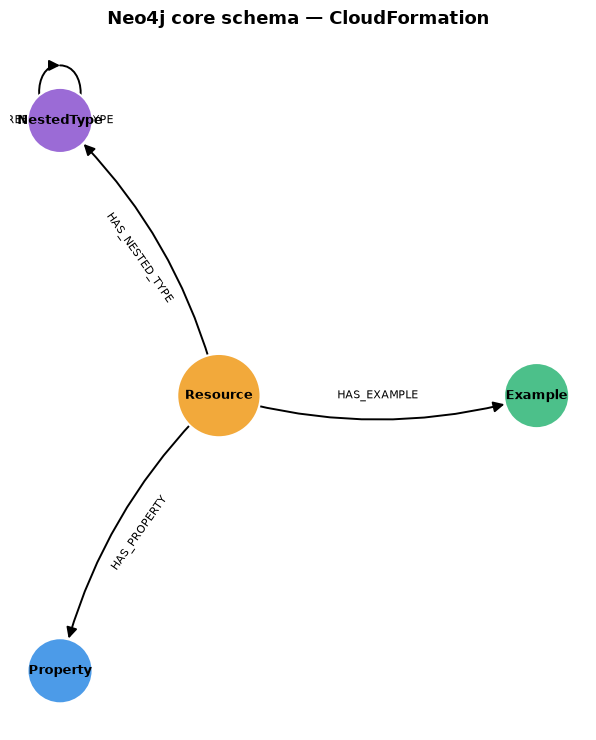

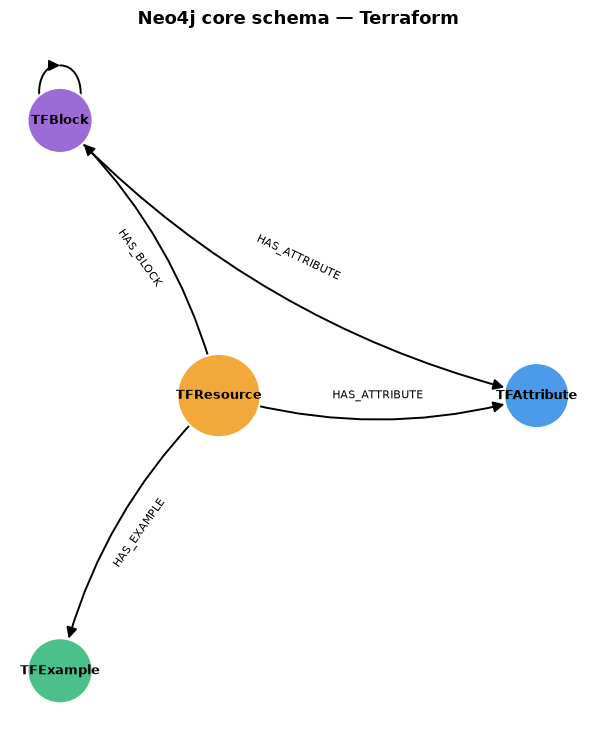

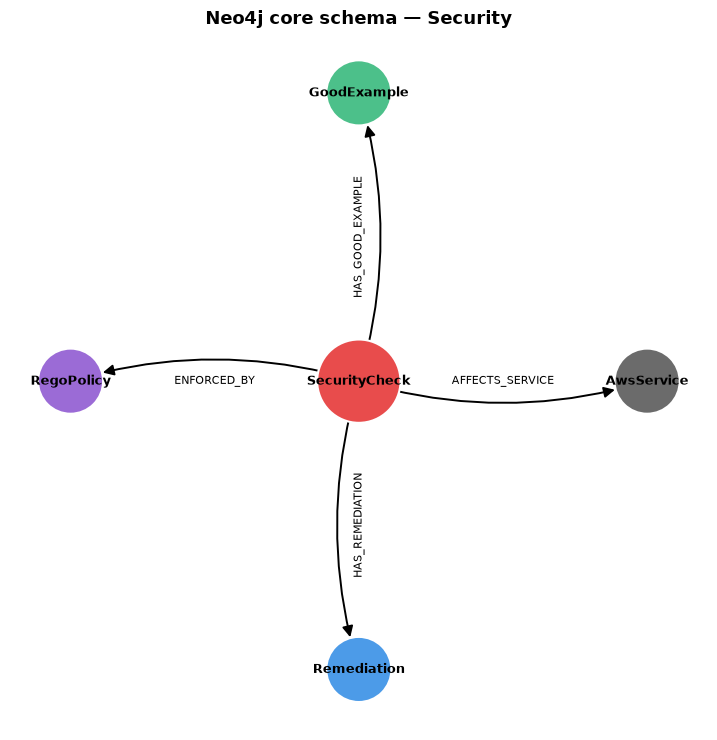

In [48]:
import math

# One colour per LABEL (not per subsystem) -- reused as-is by Sections 5-7's
# own per-type colour dicts below, so the same label always reads as the same
# colour everywhere in this notebook.
_LABEL_COLOR = {
    # CFN
    "Resource": "#F2A93B", "Property": "#4C9BE8", "NestedType": "#9B6BD6", "Example": "#4CC08A",
    # TF
    "TFResource": "#F2A93B", "TFAttribute": "#4C9BE8", "TFBlock": "#9B6BD6", "TFExample": "#4CC08A",
    # Security
    "SecurityCheck": "#E84C4C", "AwsService": "#6B6B6B", "Impact": "#F2A93B",
    "Remediation": "#4C9BE8", "GoodExample": "#4CC08A", "RegoPolicy": "#9B6BD6",
}


def _radial_layout(G: nx.DiGraph, center, ring_gap: float = 1.3) -> dict:
    """Deterministic hub-and-spoke layout, reused by every graph visualisation
    in this notebook (Sections 4-7): BFS rings out from `center`, each ring's
    nodes evenly spaced on a circle of radius = ring_index * ring_gap.

    Every graph drawn in this notebook is fundamentally star/tree-shaped -- one
    anchor node (a label, a resource, a security check) with children radiating
    out, at most one extra hop for CFN's NestedType->NestedType / TF's
    TFBlock->TFBlock self-nesting. nx.spring_layout's force simulation does not
    fit that shape well: edge length grows with node count and is sensitive to
    the `k` repulsion parameter, which is what made earlier versions of these
    plots look sparse and stretched no matter how `k` was tuned. A radial
    layout gives short, uniform, predictable edge lengths instead, deterministic
    across reruns (no seed needed).
    """
    if center not in G:
        return nx.spring_layout(G, seed=1)

    ring_of = {center: 0}
    frontier = [center]
    while frontier:
        nxt = []
        for n in frontier:
            for nb in list(G.successors(n)) + list(G.predecessors(n)):
                if nb not in ring_of:
                    ring_of[nb] = ring_of[n] + 1
                    nxt.append(nb)
        frontier = nxt
    max_ring = max(ring_of.values(), default=0)
    for n in G.nodes:
        ring_of.setdefault(n, max_ring + 1)

    rings: dict[int, list] = {}
    for n, r in ring_of.items():
        rings.setdefault(r, []).append(n)

    pos = {center: (0.0, 0.0)}
    for r, nodes in rings.items():
        if r == 0:
            continue
        nodes = sorted(nodes)
        radius = r * ring_gap
        count = len(nodes)
        for i, node in enumerate(nodes):
            angle = 2 * math.pi * i / count
            pos[node] = (radius * math.cos(angle), radius * math.sin(angle))
    return pos


def plot_core_schema(edges: list[tuple[str, str, str]], title: str, anchor: str, figsize=(7.5, 7.5)):
    """One subsystem's schema as its own diagram: the anchor label at the
    centre, every other label radiating out via _radial_layout.
    """
    G = nx.DiGraph()
    for src, rel, dst in edges:
        G.add_edge(src, dst, rel=rel)

    if G.number_of_nodes() == 0:
        print(f"No {title} schema edges to draw (is Neo4j populated? see the per-triple check above).")
        return

    pos = _radial_layout(G, anchor, ring_gap=1.3)
    node_colors = [_LABEL_COLOR.get(n, "#999999") for n in G.nodes]
    node_sizes = [3600 if n == anchor else 2200 for n in G.nodes]

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            edgecolors="white", linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=16, width=1.4, ax=ax,
                            connectionstyle="arc3,rad=0.15", min_source_margin=24, min_target_margin=24)
    edge_labels = {(u, v): d["rel"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

    ax.set_title(f"Neo4j core schema \u2014 {title}", fontweight="bold", fontsize=13)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_core_schema(edges_by_subsystem["CFN"], "CloudFormation", anchor="Resource")
plot_core_schema(edges_by_subsystem["TF"], "Terraform", anchor="TFResource")
plot_core_schema(edges_by_subsystem["Security"], "Security", anchor="SecurityCheck")


## 5 · Neo4j graph visualisation — how `query_knowledge_graph()` traverses a resource

`tools/cfn_hybrid_rag.py`'s `query_knowledge_graph()` runs one parameterised Cypher
query per resource with four sequential `OPTIONAL MATCH` stages:

```cypher
MATCH (r:Resource {name: $resource_name})
OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(prop:Property)      WHERE prop.required = true
OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(opt_prop:Property)  WHERE opt_prop.required = false
OPTIONAL MATCH (r)-[:HAS_NESTED_TYPE]->(nt:NestedType)
OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e:Example)           WHERE e.index = 0
```

Below we run that exact query (via `query_knowledge_graph()`, unmodified) for one of
the resources Query 1 surfaced, then separately pull the full node/edge neighbourhood
(including one hop of `NestedType-[:REFERENCES_TYPE]->NestedType`, which the compact
prompt renderer summarises but the graph itself contains) to draw it.

In [49]:
TARGET_RESOURCE = "AWS::EC2::SecurityGroup"  # change to inspect any other resource

res_data = rag.query_knowledge_graph(
    GraphDatabase.driver(
        os.environ["NEO4J_URI"],
        auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]),
    ),
    TARGET_RESOURCE,
)
print(rag.format_prompt_from_neo4j_result(res_data, include_example=True))

### AWS::EC2::SecurityGroup
> Specifies a security group. You must specify ingress rules to allow inbound traffic. By default, no inbound 
         traffic is allowed. When you create a security group, if you do not add egress rules, we add egress
         rules that allow all outbound IPv4 and IPv6 traffic. Otherwise, we do not add them.
         After the security group is created, if you remove all egress rules that you added,
         we do not add egress rules, so no outbound traffic is allowed.
Required: GroupDescription(String)
Optional: GroupName(String), VpcId(String)
NestedTypes: SecurityGroupIngress(opt), SecurityGroupEgress(opt), Tags(opt)
Example:
```yaml
Type: AWS::EC2::SecurityGroup
Properties:
  GroupDescription: String
  GroupName: String
  SecurityGroupEgress: 
    - Egress
  SecurityGroupIngress: 
    - Ingress
  Tags: 
    - Tag
  VpcId: String
```


### Traversal trace — the 4 `OPTIONAL MATCH` stages, run and reported individually

This instruments `query_knowledge_graph()`'s own Cypher one clause at a time so the
traversal itself — not just the final aggregated result — is visible: how many
required properties matched, how many optional properties matched, how many nested
types, and whether an example exists, in the same order Neo4j evaluates them.

In [25]:
def trace_traversal(driver, resource_name: str):
    stages = [
        ("MATCH (r:Resource {name: $n})", "MATCH (r:Resource {name:$n}) RETURN r.name AS name, r.description AS description"),
        ("OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(required)", "MATCH (r:Resource {name:$n})-[:HAS_PROPERTY]->(p:Property) WHERE p.required = true RETURN count(p) AS c"),
        ("OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(optional)", "MATCH (r:Resource {name:$n})-[:HAS_PROPERTY]->(p:Property) WHERE p.required = false RETURN count(p) AS c"),
        ("OPTIONAL MATCH (r)-[:HAS_NESTED_TYPE]->(nt)", "MATCH (r:Resource {name:$n})-[:HAS_NESTED_TYPE]->(t:NestedType) RETURN count(t) AS c"),
        ("OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e {index:0})", "MATCH (r:Resource {name:$n})-[:HAS_EXAMPLE]->(e:Example {index:0}) RETURN count(e) AS c"),
    ]
    with driver.session() as session:
        for i, (label, cypher) in enumerate(stages, start=1):
            rec = session.run(cypher, n=resource_name).single()
            if i == 1:
                found = rec is not None
                desc = ""
                if found:
                    desc_text = rec["description"] or ""
                    desc = f"  description={desc_text[:60]!r}..."
                print(f"Stage {i}: {label:<45} -> found={found}{desc}")
            else:
                print(f"Stage {i}: {label:<45} -> {rec['c']} node(s)")


driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
)
trace_traversal(driver, TARGET_RESOURCE)
driver.close()

Stage 1: MATCH (r:Resource {name: $n})                 -> found=True  description='Specifies a security group. You must specify ingress rules t'...
Stage 2: OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(required) -> 1 node(s)
Stage 3: OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(optional) -> 2 node(s)
Stage 4: OPTIONAL MATCH (r)-[:HAS_NESTED_TYPE]->(nt)   -> 3 node(s)
Stage 5: OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e {index:0}) -> 1 node(s)


In [26]:
def fetch_resource_subgraph(driver, resource_name: str, max_optional: int = 8):
    """Pull the live Neo4j neighbourhood of one Resource node into a networkx
    DiGraph, mirroring exactly the relationship types query_knowledge_graph() reads
    (HAS_PROPERTY, HAS_NESTED_TYPE, HAS_EXAMPLE) plus one hop of NestedType's own
    REFERENCES_TYPE edge, which the schema uses but the compact prompt collapses.
    """
    G = nx.DiGraph()
    G.add_node(resource_name, ntype="Resource")

    cypher = """
        MATCH (r:Resource {name: $n})
        OPTIONAL MATCH (r)-[:HAS_PROPERTY]->(p:Property)
        OPTIONAL MATCH (r)-[:HAS_NESTED_TYPE]->(nt:NestedType)
        OPTIONAL MATCH (nt)-[:REFERENCES_TYPE]->(rt:NestedType)
        OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e:Example)
        RETURN
            collect(DISTINCT {id: p.id, name: p.name, required: p.required})       AS props,
            collect(DISTINCT {id: nt.id, name: nt.name})                            AS nested,
            collect(DISTINCT {from_id: nt.id, to_id: rt.id, to_name: rt.name})      AS refs,
            collect(DISTINCT e.id)                                                  AS examples
    """
    with driver.session() as session:
        rec = session.run(cypher, n=resource_name).single()
        if not rec:
            return G

        for p in rec["props"][:max_optional]:
            if not p.get("id"):
                continue
            label = p["name"] or p["id"]
            G.add_node(p["id"], ntype="Property", required=bool(p.get("required")), label=label)
            G.add_edge(resource_name, p["id"], rel="HAS_PROPERTY")

        for nt in rec["nested"][:max_optional]:
            if not nt.get("id"):
                continue
            G.add_node(nt["id"], ntype="NestedType", label=nt["name"] or nt["id"])
            G.add_edge(resource_name, nt["id"], rel="HAS_NESTED_TYPE")

        for ref in rec["refs"]:
            if not ref.get("from_id") or not ref.get("to_id"):
                continue
            G.add_node(ref["to_id"], ntype="NestedType", label=ref["to_name"] or ref["to_id"])
            G.add_edge(ref["from_id"], ref["to_id"], rel="REFERENCES_TYPE")

        for ex_id in rec["examples"]:
            if not ex_id:
                continue
            G.add_node(ex_id, ntype="Example", label=ex_id)
            G.add_edge(resource_name, ex_id, rel="HAS_EXAMPLE")

    return G


driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
)
resource_graph = fetch_resource_subgraph(driver, TARGET_RESOURCE)
driver.close()

print(f"{resource_graph.number_of_nodes()} node(s), {resource_graph.number_of_edges()} edge(s)")

14 node(s), 13 edge(s)


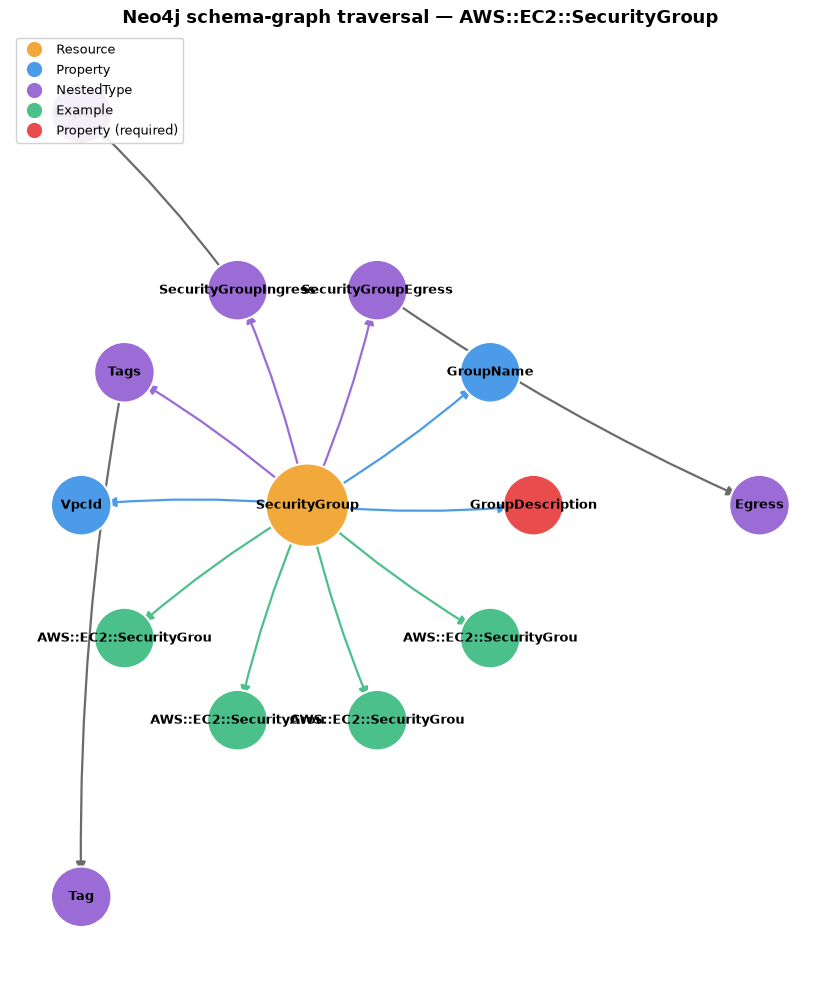

In [46]:
_NTYPE_COLOR = {
    "Resource":   "#F2A93B",
    "Property":   "#4C9BE8",
    "NestedType": "#9B6BD6",
    "Example":    "#4CC08A",
}
_REQ_COLOR = "#E84C4C"  # required properties drawn in red regardless of ntype fill


def plot_resource_subgraph(G: nx.DiGraph, resource_name: str, figsize=(10, 10)):
    if G.number_of_nodes() <= 1:
        print(f"No graph data for {resource_name} -- is Neo4j populated/reachable?")
        return

    # _radial_layout, defined in Section 4: a hub-and-spoke graph like this one
    # (one Resource with properties/nested types/example radiating out, at
    # most one extra REFERENCES_TYPE hop) gets short, predictable edges from a
    # deterministic BFS-ring layout, unlike spring_layout's force simulation.
    pos = _radial_layout(G, resource_name, ring_gap=1.8)

    node_colors, node_sizes, labels = [], [], {}
    for n, d in G.nodes(data=True):
        ntype = d.get("ntype", "?")
        if ntype == "Property" and d.get("required"):
            node_colors.append(_REQ_COLOR)
        else:
            node_colors.append(_NTYPE_COLOR.get(ntype, "#999999"))
        node_sizes.append(3600 if ntype == "Resource" else 1900)
        labels[n] = resource_name.split("::")[-1] if n == resource_name else d.get("label", n)[:22]

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            edgecolors="white", linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold", ax=ax)

    edge_colors = {
        "HAS_PROPERTY": "#4C9BE8", "HAS_NESTED_TYPE": "#9B6BD6",
        "REFERENCES_TYPE": "#6B6B6B", "HAS_EXAMPLE": "#4CC08A",
    }
    for rel, color in edge_colors.items():
        elist = [(u, v) for u, v, d in G.edges(data=True) if d.get("rel") == rel]
        nx.draw_networkx_edges(G, pos, edgelist=elist, edge_color=color, arrows=True,
                                arrowsize=14, width=1.6, ax=ax, connectionstyle="arc3,rad=0.05",
                                min_source_margin=18, min_target_margin=18)

    legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=12, label=k)
              for k, c in {**_NTYPE_COLOR, "Property (required)": _REQ_COLOR}.items()]
    ax.legend(handles=legend, loc="upper left", fontsize=9, framealpha=0.9)
    ax.set_title(f"Neo4j schema-graph traversal \u2014 {resource_name}", fontweight="bold", fontsize=13)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_resource_subgraph(resource_graph, TARGET_RESOURCE)


## 6 · Neo4j graph visualisation — the Terraform `TFResource` subgraph

Mirrors Section 5 for Terraform. `tools/tf_hybrid_rag.py`'s `query_knowledge_graph()`
runs the same four-stage shape against the TF graph:

```cypher
MATCH (r:TFResource {name: $resource_name})
OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(req_attr:TFAttribute) WHERE req_attr.required = true
OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(opt_attr:TFAttribute) WHERE opt_attr.required = false
OPTIONAL MATCH (r)-[:HAS_BLOCK]->(b:TFBlock)
OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e:TFExample)
```

**One real schema-shape difference from CFN, not just a naming difference.** CFN's
`NestedType` is a shared, referenceable pool: a `NestedType` node can be pointed to
by `REFERENCES_TYPE` edges from other `NestedType` nodes anywhere in the graph
(a genuinely graph-shaped structure). Terraform's `TFBlock` is not a shared pool --
it nests directly and only within its own owning resource via `HAS_BLOCK`, including
`TFBlock -[:HAS_BLOCK]-> TFBlock` for blocks nested inside blocks (a tree rooted at
one `TFResource`, not a graph shared across resources). The subgraph fetch below
walks one hop of that self-nesting to make the shape visible, the direct TF analogue
of Section 5's one hop of `NestedType-[:REFERENCES_TYPE]->NestedType`.

In [28]:
TARGET_TF_RESOURCE = "aws_security_group"  # same conceptual resource as Section 5's example

from tools import tf_hybrid_rag as tfrag

driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
)
tf_res_data = tfrag.query_knowledge_graph(driver, TARGET_TF_RESOURCE)
driver.close()
print(tfrag.format_prompt_from_neo4j_result(tf_res_data, include_example=True))


### aws_security_group
Required: None(None)
Optional: vpc_id(string) — (Optional) Id of the VPC that the desired security group belongs to., tags_all(map(string)), tags(map(string)) — (Optional) Map of tags, each pair of which must exactly match, revoke_rules_on_delete(bool), region(string) — Region where this resource will be [managed](https://docs.aws.amazon.com/general/latest/gr/rande.html#regional-endpoints). Defaults to the Region set in the [provider configuration](https://registry.terraform.io/providers/hashicorp/aws/latest/docs#aws-configuration-reference)., owner_id(string), name_prefix(string), name(string) — (Optional) Name that the desired security group must have., ingress(set(object({'cidr_blocks': ['list', 'string'], 'description': 'string', 'from_port': 'number', 'ipv6_cidr_blocks': ['list', 'string'], 'prefix_list_ids': ['list', 'string'], 'protocol': 'string', 'security_groups': ['set', 'string'], 'self': 'bool', 'to_port': 'number'}))), id(string) — (Optional) Id of 

### Traversal trace — the 4 `OPTIONAL MATCH` stages, run and reported individually

Same instrumentation as Section 5's `trace_traversal()`, against the TF Cypher shape.

In [29]:
def trace_traversal_tf(driver, resource_name: str):
    stages = [
        ("MATCH (r:TFResource {name: $n})",
         "MATCH (r:TFResource {name:$n}) RETURN r.name AS name, r.description AS description"),
        ("OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(required)",
         "MATCH (r:TFResource {name:$n})-[:HAS_ATTRIBUTE]->(a:TFAttribute) WHERE a.required = true RETURN count(a) AS c"),
        ("OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(optional)",
         "MATCH (r:TFResource {name:$n})-[:HAS_ATTRIBUTE]->(a:TFAttribute) WHERE a.required = false RETURN count(a) AS c"),
        ("OPTIONAL MATCH (r)-[:HAS_BLOCK]->(b)",
         "MATCH (r:TFResource {name:$n})-[:HAS_BLOCK]->(b:TFBlock) RETURN count(b) AS c"),
        ("OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e)",
         "MATCH (r:TFResource {name:$n})-[:HAS_EXAMPLE]->(e:TFExample) RETURN count(e) AS c"),
    ]
    with driver.session() as session:
        for i, (label, cypher) in enumerate(stages, start=1):
            rec = session.run(cypher, n=resource_name).single()
            if i == 1:
                found = rec is not None
                desc = ""
                if found:
                    desc_text = rec["description"] or ""
                    desc = f"  description={desc_text[:60]!r}..."
                print(f"Stage {i}: {label:<40} -> found={found}{desc}")
            else:
                print(f"Stage {i}: {label:<40} -> {rec['c']} node(s)")


driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
)
trace_traversal_tf(driver, TARGET_TF_RESOURCE)
driver.close()


Stage 1: MATCH (r:TFResource {name: $n})          -> found=True  description=''...
Stage 2: OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(required) -> 0 node(s)
Stage 3: OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(optional) -> 13 node(s)
Stage 4: OPTIONAL MATCH (r)-[:HAS_BLOCK]->(b)     -> 1 node(s)
Stage 5: OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e)   -> 1 node(s)


In [30]:
def fetch_tf_resource_subgraph(driver, resource_name: str, max_optional: int = 8):
    """Pull the live Neo4j neighbourhood of one TFResource node into a networkx
    DiGraph. Mirrors fetch_resource_subgraph() exactly in shape, reading
    HAS_ATTRIBUTE / HAS_BLOCK / HAS_EXAMPLE plus one hop of TFBlock's own
    self-nesting HAS_BLOCK edge (the TF analogue of NestedType-REFERENCES_TYPE).
    """
    G = nx.DiGraph()
    G.add_node(resource_name, ntype="TFResource")

    cypher = """
        MATCH (r:TFResource {name: $n})
        OPTIONAL MATCH (r)-[:HAS_ATTRIBUTE]->(a:TFAttribute)
        OPTIONAL MATCH (r)-[:HAS_BLOCK]->(b:TFBlock)
        OPTIONAL MATCH (b)-[:HAS_BLOCK]->(nb:TFBlock)
        OPTIONAL MATCH (r)-[:HAS_EXAMPLE]->(e:TFExample)
        RETURN
            collect(DISTINCT {id: a.id, name: a.name, required: a.required})   AS attrs,
            collect(DISTINCT {id: b.id, name: b.name})                        AS blocks,
            collect(DISTINCT {from_id: b.id, to_id: nb.id, to_name: nb.name}) AS nested_blocks,
            collect(DISTINCT e.id)                                            AS examples
    """
    with driver.session() as session:
        rec = session.run(cypher, n=resource_name).single()
        if not rec:
            return G

        for a in rec["attrs"][:max_optional]:
            if not a.get("id"):
                continue
            label = a["name"] or a["id"]
            G.add_node(a["id"], ntype="TFAttribute", required=bool(a.get("required")), label=label)
            G.add_edge(resource_name, a["id"], rel="HAS_ATTRIBUTE")

        for b in rec["blocks"][:max_optional]:
            if not b.get("id"):
                continue
            G.add_node(b["id"], ntype="TFBlock", label=b["name"] or b["id"])
            G.add_edge(resource_name, b["id"], rel="HAS_BLOCK")

        for nb in rec["nested_blocks"]:
            if not nb.get("from_id") or not nb.get("to_id"):
                continue
            G.add_node(nb["to_id"], ntype="TFBlock", label=nb["to_name"] or nb["to_id"])
            G.add_edge(nb["from_id"], nb["to_id"], rel="HAS_BLOCK")

        for ex_id in rec["examples"]:
            if not ex_id:
                continue
            G.add_node(ex_id, ntype="TFExample", label=ex_id)
            G.add_edge(resource_name, ex_id, rel="HAS_EXAMPLE")

    return G


driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
)
tf_resource_graph = fetch_tf_resource_subgraph(driver, TARGET_TF_RESOURCE)
driver.close()

print(f"{tf_resource_graph.number_of_nodes()} node(s), {tf_resource_graph.number_of_edges()} edge(s)")


11 node(s), 10 edge(s)


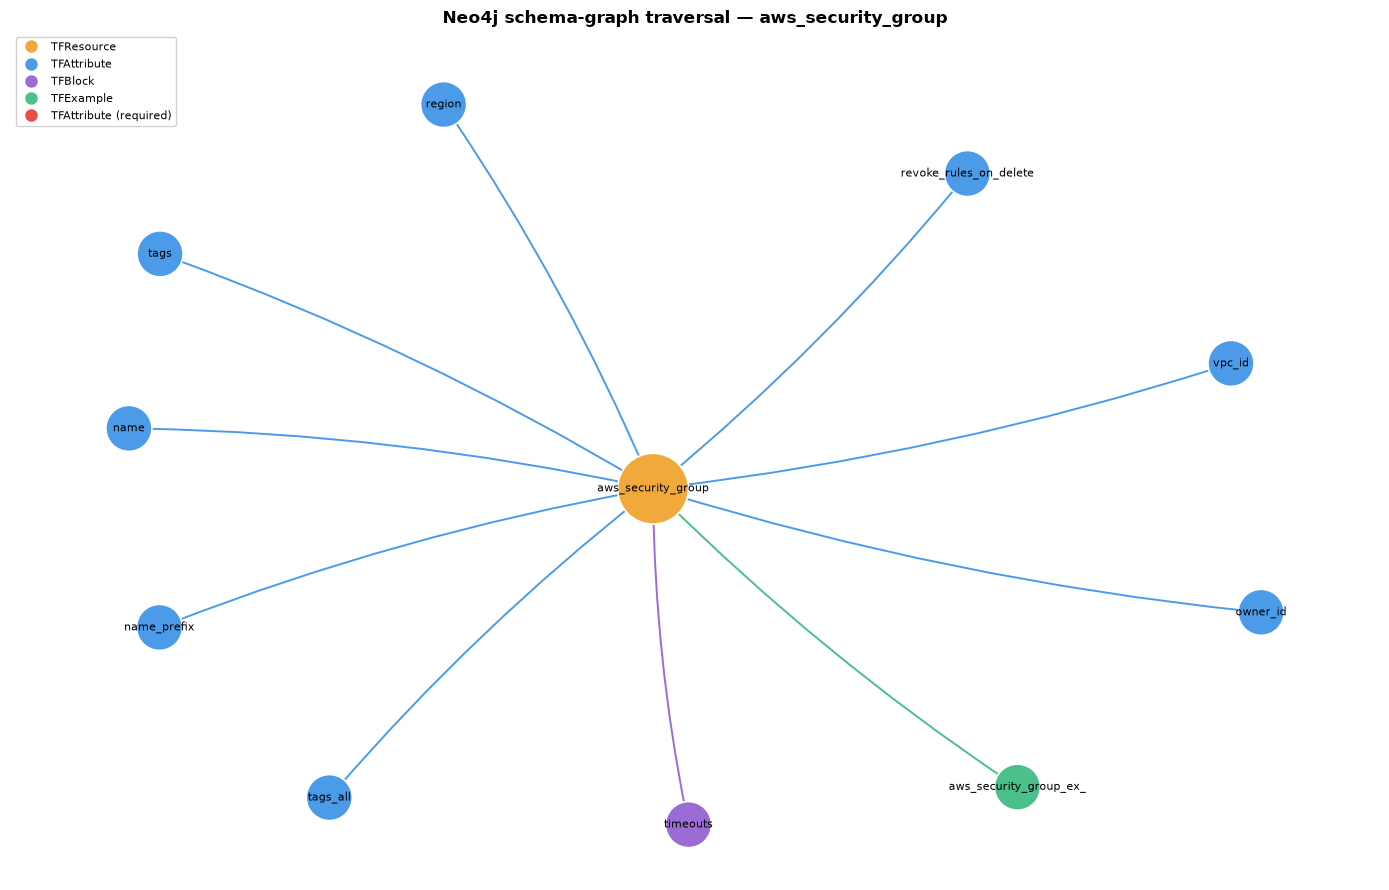

In [31]:
_TF_NTYPE_COLOR = {
    "TFResource":  "#F2A93B",  # same role/colour as CFN's Resource
    "TFAttribute": "#4C9BE8",  # same role/colour as CFN's Property
    "TFBlock":     "#9B6BD6",  # same role/colour as CFN's NestedType
    "TFExample":   "#4CC08A",  # same role/colour as CFN's Example
}
_TF_REQ_COLOR = "#E84C4C"  # required attributes drawn in red, matching Section 5


def plot_tf_resource_subgraph(G: nx.DiGraph, resource_name: str, figsize=(10, 10)):
    if G.number_of_nodes() <= 1:
        print(f"No graph data for {resource_name} -- is Neo4j populated/reachable?")
        return

    # _radial_layout, defined in Section 4 -- see plot_resource_subgraph's own
    # comment (Section 5) for why this replaces spring_layout here too.
    pos = _radial_layout(G, resource_name, ring_gap=1.8)

    node_colors, node_sizes, labels = [], [], {}
    for n, d in G.nodes(data=True):
        ntype = d.get("ntype", "?")
        if ntype == "TFAttribute" and d.get("required"):
            node_colors.append(_TF_REQ_COLOR)
        else:
            node_colors.append(_TF_NTYPE_COLOR.get(ntype, "#999999"))
        node_sizes.append(3600 if ntype == "TFResource" else 1900)
        labels[n] = resource_name if n == resource_name else d.get("label", n)[:22]

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            edgecolors="white", linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold", ax=ax)

    edge_colors = {
        "HAS_ATTRIBUTE": "#4C9BE8", "HAS_BLOCK": "#9B6BD6", "HAS_EXAMPLE": "#4CC08A",
    }
    for rel, color in edge_colors.items():
        elist = [(u, v) for u, v, d in G.edges(data=True) if d.get("rel") == rel]
        nx.draw_networkx_edges(G, pos, edgelist=elist, edge_color=color, arrows=True,
                                arrowsize=14, width=1.6, ax=ax, connectionstyle="arc3,rad=0.05",
                                min_source_margin=18, min_target_margin=18)

    legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=12, label=k)
              for k, c in {**_TF_NTYPE_COLOR, "TFAttribute (required)": _TF_REQ_COLOR}.items()]
    ax.legend(handles=legend, loc="upper left", fontsize=9, framealpha=0.9)
    ax.set_title(f"Neo4j schema-graph traversal \u2014 {resource_name}", fontweight="bold", fontsize=13)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_tf_resource_subgraph(tf_resource_graph, TARGET_TF_RESOURCE)


## 7 · Neo4j graph visualisation — the SecurityCheck subgraph (Trivy path)

Mirrors Section 5 for the security graph `04_import_security_to_neo4j.py` builds:
`SecurityCheck -[:HAS_IMPACT]-> Impact`, `-[:HAS_REMEDIATION]-> Remediation`
(framework-filtered), `-[:HAS_GOOD_EXAMPLE]-> GoodExample` (framework-filtered),
`-[:ENFORCED_BY]-> RegoPolicy`, `-[:AFFECTS_SERVICE]-> AwsService`, and
`-[:APPLIES_TO_RESOURCE]-> Resource` — the last of which is the one edge that
crosses over into the very same `Resource` nodes Section 4 visualised, i.e. Neo4j
holds a single connected knowledge graph, not two separate databases.

The sample template's own findings (`AWS-0028`, `AWS-0131`) may or may not be
present in whichever slice of the Trivy AVD catalogue this Neo4j instance was built
from — `SecurityCheck` count from the connectivity check above is a partial import,
not necessarily the full catalogue, and an `Impact` count of 0 there already signals
that stage of `04_import_security_to_neo4j.py` may not have been (re)run. The cell
below resolves a check_id that is actually populated (via `_id_variants()`, the same
AVD-AWS-XXXX/AWS-XXXX normalisation `security_hybrid_rag.py` itself applies) so the
graph traversal below always has something real to draw, independent of which exact
checks happen to be loaded right now — falling back to any populated `SecurityCheck`
only if neither of the sample's own findings resolve.

In [32]:
def resolve_populated_check_id(candidate_ids: list[str]) -> str | None:
    driver = GraphDatabase.driver(
        os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
    )
    try:
        with driver.session() as session:
            for cid in candidate_ids:
                for variant in secrag._id_variants(cid):
                    rec = session.run(
                        "MATCH (s:SecurityCheck {check_id: $cid}) RETURN s.check_id AS id",
                        cid=variant,
                    ).single()
                    if rec:
                        return rec["id"]
            # None of the sample scenario's own findings are in this graph —
            # fall back to any populated SecurityCheck so the visualisation
            # below still has real data to draw.
            rec = session.run("MATCH (s:SecurityCheck) RETURN s.check_id AS id LIMIT 1").single()
            return rec["id"] if rec else None
    finally:
        driver.close()


VIZ_CHECK_ID = resolve_populated_check_id(check_ids)
if VIZ_CHECK_ID and VIZ_CHECK_ID not in check_ids:
    print(
        f"Neither {check_ids} resolved in this Neo4j instance — "
        f"falling back to a populated check for the visualisation: {VIZ_CHECK_ID!r}"
    )
else:
    print(f"Visualising: {VIZ_CHECK_ID!r}")

Neither ['AWS-0028', 'AWS-0131'] resolved in this Neo4j instance — falling back to a populated check for the visualisation: 'AVD-AWS-0028'


In [33]:
def fetch_security_subgraph(driver, check_id: str, frameworks: list[str]):
    G = nx.DiGraph()
    G.add_node(check_id, ntype="SecurityCheck")

    cypher = """
        MATCH (s:SecurityCheck {check_id: $cid})
        OPTIONAL MATCH (s)-[:HAS_IMPACT]->(imp:Impact)
        OPTIONAL MATCH (s)-[:HAS_REMEDIATION]->(rem:Remediation) WHERE rem.framework IN $fw
        OPTIONAL MATCH (s)-[:HAS_GOOD_EXAMPLE]->(ex:GoodExample) WHERE ex.framework IN $fw
        OPTIONAL MATCH (s)-[:ENFORCED_BY]->(rp:RegoPolicy)
        OPTIONAL MATCH (s)-[:AFFECTS_SERVICE]->(svc:AwsService)
        OPTIONAL MATCH (s)-[:APPLIES_TO_RESOURCE]->(res:Resource)
        RETURN
            collect(DISTINCT imp.id)   AS impacts,
            collect(DISTINCT rem.id)   AS remediations,
            collect(DISTINCT ex.id)    AS examples,
            collect(DISTINCT rp.id)    AS regos,
            collect(DISTINCT svc.name) AS services,
            collect(DISTINCT res.name) AS resources
    """
    with driver.session() as session:
        rec = session.run(cypher, cid=check_id, fw=frameworks).single()
        if not rec:
            return G
        edge_specs = [
            ("impacts", "Impact", "HAS_IMPACT"),
            ("remediations", "Remediation", "HAS_REMEDIATION"),
            ("examples", "GoodExample", "HAS_GOOD_EXAMPLE"),
            ("regos", "RegoPolicy", "ENFORCED_BY"),
            ("services", "AwsService", "AFFECTS_SERVICE"),
            ("resources", "Resource", "APPLIES_TO_RESOURCE"),
        ]
        for key, ntype, rel in edge_specs:
            for node_id in rec[key]:
                if not node_id:
                    continue
                G.add_node(node_id, ntype=ntype, label=str(node_id)[:24])
                G.add_edge(check_id, node_id, rel=rel)
    return G


if VIZ_CHECK_ID:
    frameworks = secrag._FRAMEWORK_FILTERS.get(state["iac_type"], ["cfn", "cloudformation"])
    driver = GraphDatabase.driver(
        os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"])
    )
    security_graph = fetch_security_subgraph(driver, VIZ_CHECK_ID, frameworks)
    driver.close()
    print(f"{security_graph.number_of_nodes()} node(s), {security_graph.number_of_edges()} edge(s) "
          f"for {VIZ_CHECK_ID}")
else:
    security_graph = nx.DiGraph()
    print("No check IDs extracted from the Trivy findings — nothing to visualise.")

124 node(s), 123 edge(s) for AVD-AWS-0028


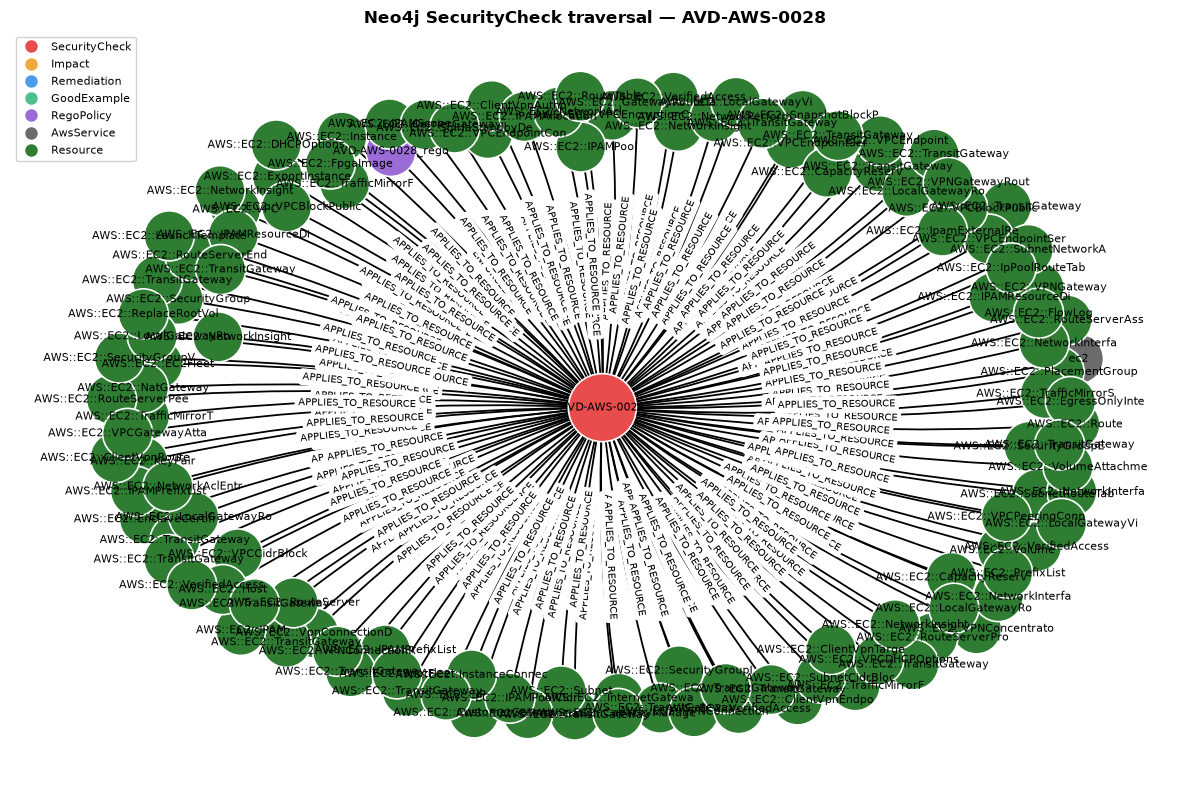

In [34]:
_SEC_NTYPE_COLOR = {
    "SecurityCheck": "#E84C4C",
    "Impact":        "#F2A93B",
    "Remediation":   "#4C9BE8",
    "GoodExample":   "#4CC08A",
    "RegoPolicy":    "#9B6BD6",
    "AwsService":    "#6B6B6B",
    "Resource":      "#2E7D32",  # matches the cross-link into the CFN schema graph
}


def plot_security_subgraph(G: nx.DiGraph, check_id: str, figsize=(9, 9)):
    if G.number_of_nodes() <= 1:
        print(f"No graph data for {check_id} -- is the security graph populated/reachable?")
        return

    # _radial_layout, defined in Section 4 -- see plot_resource_subgraph's own
    # comment (Section 5) for why this replaces spring_layout here too.
    pos = _radial_layout(G, check_id, ring_gap=1.6)
    node_colors = [_SEC_NTYPE_COLOR.get(d.get("ntype", "?"), "#999999") for _, d in G.nodes(data=True)]
    node_sizes = [3400 if n == check_id else 1900 for n in G.nodes()]
    labels = {n: (check_id if n == check_id else d.get("label", n)) for n, d in G.nodes(data=True)}

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            edgecolors="white", linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=14, width=1.5, ax=ax,
                            connectionstyle="arc3,rad=0.05", min_source_margin=20, min_target_margin=20)
    edge_labels = {(u, v): d["rel"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

    legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=12, label=k)
              for k, c in _SEC_NTYPE_COLOR.items()]
    ax.legend(handles=legend, loc="upper left", fontsize=9, framealpha=0.9)
    ax.set_title(f"Neo4j SecurityCheck traversal \u2014 {check_id}", fontweight="bold", fontsize=13)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


if VIZ_CHECK_ID:
    plot_security_subgraph(security_graph, VIZ_CHECK_ID)


## 8 · N-hop dependency-graph traversal — an experiment beyond the current retriever

**Scope note.** Everything up to this point simulates `agents/retriever.py` exactly
as shipped. This section is different on purpose: `query_knowledge_graph()` only
ever looks up a resource's own **schema** neighbourhood (its properties/nested
types/examples) — it never walks *between* resources in the template being fixed.
`seed_resources`/`error_resources` are always flat sets, not a graph, so the current
retriever cannot answer "what else might be affected if I change this resource?".

This section builds that missing piece — a **template-instance dependency graph**
(which resource `Ref`/`Fn::GetAtt`/`DependsOn`s which other resource) — purely from
the sample template's own AST via `tools/template_annotator.py`'s `_CFNTag`
representation, then shows what a 1-hop vs. 2-hop vs. full-graph traversal from an
erroring resource would pull into the Neo4j schema-retrieval context. It's an
exploratory ablation for the "would deeper graph traversal help fix
dependency-shaped errors" question, not a claim about what the shipped code does.

In [35]:
# A richer template than Sections 1-3's — a genuine dependency chain
# (VPC -> Subnet/SecurityGroup -> Instance -> ElasticIP -> DNS record) so 1-hop and
# 2-hop neighbourhoods are visibly different sizes. DemoSecurityGroup carries the
# same IpProtcol typo as Query 1's scenario, so it plays the role of "the resource
# with an active error" here.
DEPENDENCY_DEMO_TEMPLATE = textwrap.dedent("""
    AWSTemplateFormatVersion: "2010-09-09"
    Description: Dependency-chain demo for N-hop GraphRAG traversal.

    Resources:
      DemoVPC:
        Type: AWS::EC2::VPC
        Properties:
          CidrBlock: 10.0.0.0/16

      DemoSubnet:
        Type: AWS::EC2::Subnet
        Properties:
          VpcId: !Ref DemoVPC
          CidrBlock: 10.0.1.0/24
          AvailabilityZone: us-east-1a

      DemoSecurityGroup:
        Type: AWS::EC2::SecurityGroup
        Properties:
          GroupDescription: Demo SG with the same intentional lint bug as Query 1
          VpcId: !Ref DemoVPC
          SecurityGroupIngress:
            - IpProtcol: tcp
              FromPort: 443
              ToPort: 443
              CidrIp: 0.0.0.0/0

      DemoInstance:
        Type: AWS::EC2::Instance
        Properties:
          InstanceType: t3.micro
          ImageId: ami-00000000000000000
          SubnetId: !Ref DemoSubnet
          SecurityGroupIds:
            - !GetAtt DemoSecurityGroup.GroupId

      DemoElasticIp:
        Type: AWS::EC2::EIP
        DependsOn: DemoInstance
        Properties:
          Domain: vpc
          InstanceId: !Ref DemoInstance

      DemoDnsRecord:
        Type: AWS::Route53::RecordSet
        Properties:
          HostedZoneId: Z0000000000000EXAMPLE
          Name: demo.example.com
          Type: A
          TTL: "300"
          ResourceRecords:
            - !GetAtt DemoElasticIp.PublicIp
""").strip() + "\n"

dep_lint_result = validators.validate_cfn_lint(DEPENDENCY_DEMO_TEMPLATE)
dep_annotation = _annotate_safely(
    template=DEPENDENCY_DEMO_TEMPLATE, smell_report=None, iac_type="cloudformation"
)

print(f"[cfn-lint] passed={dep_lint_result['passed']}  {len(dep_lint_result['errors'])} error(s)")
for e in dep_lint_result["errors"]:
    print(f"  - {e}")

FOCUS_RESOURCE_ID = "DemoSecurityGroup"  # the resource with the active error
print(f"\nFOCUS_RESOURCE_ID = {FOCUS_RESOURCE_ID!r}")

[Retriever] Annotation: 6 resources parsed.
[cfn-lint] passed=False  4 error(s)
  - [W3010] | line 15 | Resource: DemoSubnet | Avoid hardcoding availability zones 'us-east-1a' | Check if an Availability Zone property is hardcoded.
  - [E3002] | line 23 | Resource: DemoSecurityGroup | Additional properties are not allowed ('IpProtcol' was unexpected. Did you mean 'IpProtocol'?) | Making sure that resources properties are properly configured
  - [E3003] | line 23 | Resource: DemoSecurityGroup | 'IpProtocol' is a required property | Make sure that Resources properties that are required exist
  - [W3005] | line 39 | Resource: DemoElasticIp | 'DemoInstance' dependency already enforced by a 'Ref' at 'Resources/DemoElasticIp/Properties/InstanceId' | Check if DependsOn is specified if not needed. A Ref or a Fn::GetAtt already is an implicit dependency.

FOCUS_RESOURCE_ID = 'DemoSecurityGroup'


In [36]:
def _iter_refs(node):
    """Yield every logical-ID string referenced via Ref/Fn::GetAtt anywhere inside
    node, handling both the short-form !Ref/!GetAtt (_CFNTag instances, as produced
    by template_annotator's custom YAML loader) and the long-form Ref:/Fn::GetAtt:
    plain-dict style.
    """
    if isinstance(node, ta._CFNTag):
        # _CFNTag.tag keeps the leading "!" (e.g. "!Ref", "!GetAtt") — see
        # _CFNTag.to_dict()'s own `tag.lstrip("!")` for the same normalisation.
        tag = node.tag.lstrip("!")
        if tag == "Ref" and isinstance(node.value, str):
            yield node.value
        elif tag == "GetAtt":
            v = node.value
            if isinstance(v, str):
                yield v.split(".")[0]
            elif isinstance(v, list) and v:
                yield v[0]
        else:
            yield from _iter_refs(node.value)
    elif isinstance(node, dict):
        if isinstance(node.get("Ref"), str):
            yield node["Ref"]
        get_att = node.get("Fn::GetAtt")
        if isinstance(get_att, str):
            yield get_att.split(".")[0]
        elif isinstance(get_att, list) and get_att:
            yield get_att[0]
        for v in node.values():
            yield from _iter_refs(v)
    elif isinstance(node, list):
        for item in node:
            yield from _iter_refs(item)


def build_dependency_graph(annotation: ta.TemplateAnnotation) -> nx.DiGraph:
    """Build a resource-instance dependency graph: edge (A -> B) means
    "A's definition references B" (via Ref, Fn::GetAtt, or DependsOn).
    This is deliberately separate from the AWS-schema graph in Neo4j — it captures
    *this specific template's* wiring, not general AWS resource-type schema.
    """
    resource_ids = {r.resource_id for r in annotation.resources}
    G = nx.DiGraph()
    for r in annotation.resources:
        G.add_node(r.resource_id, resource_type=r.resource_type)

    for r in annotation.resources:
        depends_on = r.raw.get("DependsOn")
        if isinstance(depends_on, str):
            depends_on = [depends_on]
        for dep in depends_on or []:
            if dep in resource_ids and dep != r.resource_id:
                G.add_edge(r.resource_id, dep, via="DependsOn")

        for ref_id in _iter_refs(r.raw.get("Properties", {})):
            if ref_id in resource_ids and ref_id != r.resource_id:
                G.add_edge(r.resource_id, ref_id, via="Ref/GetAtt")

    return G


dependency_graph = build_dependency_graph(dep_annotation)
print(f"{dependency_graph.number_of_nodes()} resource(s), "
      f"{dependency_graph.number_of_edges()} dependency edge(s):")
for u, v, d in dependency_graph.edges(data=True):
    print(f"  {u}  --[{d['via']}]-->  {v}")

6 resource(s), 6 dependency edge(s):
  DemoSubnet  --[Ref/GetAtt]-->  DemoVPC
  DemoSecurityGroup  --[Ref/GetAtt]-->  DemoVPC
  DemoInstance  --[Ref/GetAtt]-->  DemoSubnet
  DemoInstance  --[Ref/GetAtt]-->  DemoSecurityGroup
  DemoElasticIp  --[Ref/GetAtt]-->  DemoInstance
  DemoDnsRecord  --[Ref/GetAtt]-->  DemoElasticIp


### 1-hop vs. 2-hop vs. full-graph neighbourhoods around the erroring resource

`nx.ego_graph(..., radius=k, undirected=True)` gives the same kind of "expand from a
seed node by k hops" traversal a GraphRAG system would use to widen context — computed
on the undirected view (a dependency can matter whether *this* resource references
the neighbour or is referenced by it), while keeping the real edge directions for
the drawing.

In [37]:
undirected_view = dependency_graph.to_undirected()
hop_graphs = {
    k: nx.ego_graph(dependency_graph, FOCUS_RESOURCE_ID, radius=k, undirected=True)
    for k in (1, 2, 3)
}

for k, hg in hop_graphs.items():
    others = sorted(n for n in hg.nodes if n != FOCUS_RESOURCE_ID)
    print(f"{k}-hop neighbourhood ({len(others)} other resource(s)): {others}")

1-hop neighbourhood (2 other resource(s)): ['DemoInstance', 'DemoVPC']
2-hop neighbourhood (4 other resource(s)): ['DemoElasticIp', 'DemoInstance', 'DemoSubnet', 'DemoVPC']
3-hop neighbourhood (5 other resource(s)): ['DemoDnsRecord', 'DemoElasticIp', 'DemoInstance', 'DemoSubnet', 'DemoVPC']


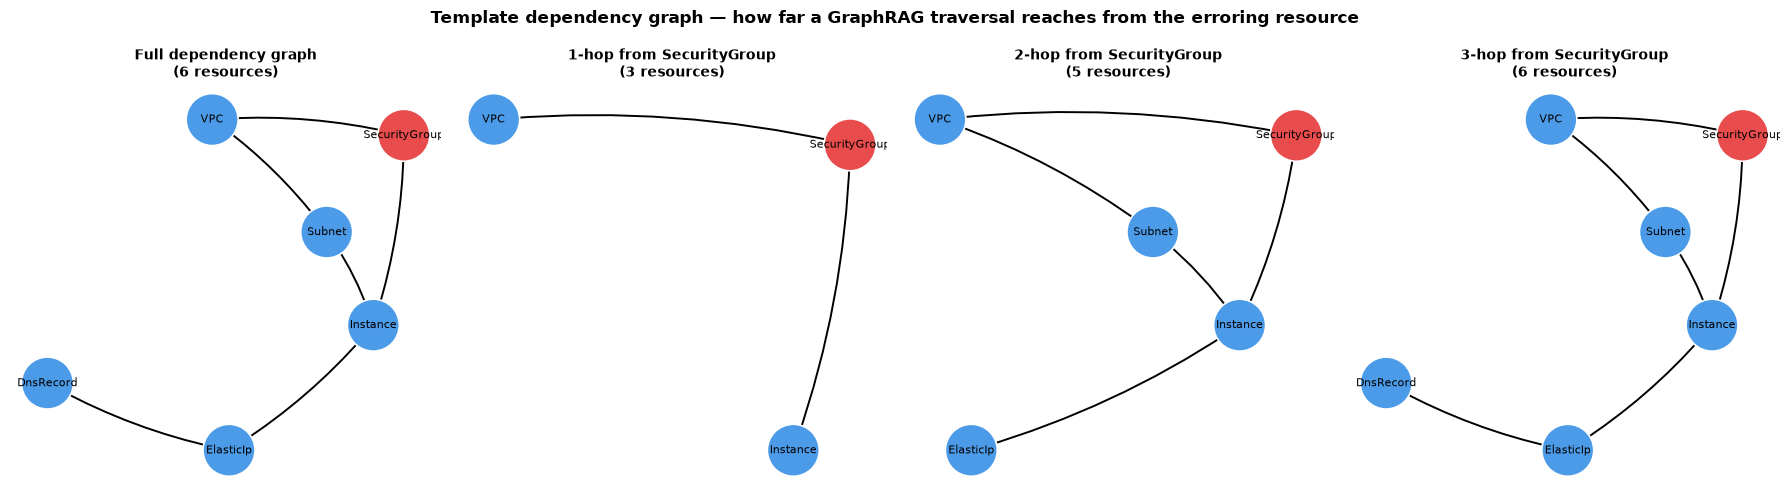

In [38]:
_DEP_TYPE_COLOR_FALLBACK = "#4C9BE8"
_FOCUS_COLOR = "#E84C4C"


def plot_dependency_hops(full_graph: nx.DiGraph, hop_graphs: dict, focus: str, figsize=(18, 5)):
    pos = nx.spring_layout(full_graph, seed=3, k=1.1)
    fig, axes = plt.subplots(1, len(hop_graphs) + 1, figsize=figsize)

    def _draw(ax, G, title):
        node_colors = [_FOCUS_COLOR if n == focus else _DEP_TYPE_COLOR_FALLBACK for n in G.nodes]
        sub_pos = {n: pos[n] for n in G.nodes}
        nx.draw_networkx_nodes(G, sub_pos, node_color=node_colors, node_size=1400,
                                edgecolors="white", linewidths=1.2, ax=ax)
        nx.draw_networkx_labels(
            G, sub_pos,
            labels={n: n.replace("Demo", "") for n in G.nodes},
            font_size=8, ax=ax,
        )
        nx.draw_networkx_edges(G, sub_pos, arrows=True, arrowsize=14, width=1.4, ax=ax,
                                connectionstyle="arc3,rad=0.08")
        ax.set_title(title, fontweight="bold", fontsize=10)
        ax.axis("off")

    _draw(axes[0], full_graph, f"Full dependency graph\n({full_graph.number_of_nodes()} resources)")
    for ax, (k, hg) in zip(axes[1:], hop_graphs.items()):
        _draw(ax, hg, f"{k}-hop from {focus.replace('Demo', '')}\n({hg.number_of_nodes()} resources)")

    fig.suptitle(
        "Template dependency graph — how far a GraphRAG traversal reaches from the erroring resource",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


plot_dependency_hops(dependency_graph, hop_graphs, FOCUS_RESOURCE_ID)

### What each hop depth would actually pull into the Neo4j schema context

For each hop depth, map the resources in that neighbourhood to their AWS types and
run them through the exact same `rag._graph_schema_lookup()` (Stage 2, real Neo4j
traversal — same function `execute_hybrid_retrieval()` calls) used everywhere else
in this notebook. This is the concrete tradeoff a deeper-hop retriever would face:
more resources covered, but a larger context block per iteration.

In [39]:
type_by_id = {r.resource_id: r.resource_type for r in dep_annotation.resources}

hop_rows = []
for k in (0, 1, 2, 3):
    if k == 0:
        node_ids = {FOCUS_RESOURCE_ID}
    else:
        node_ids = set(hop_graphs[k].nodes)
    resource_types = {type_by_id[n] for n in node_ids if n in type_by_id}

    schema_blocks = rag._graph_schema_lookup(
        resource_types, chroma_covered=set(), error_resources=None,
    )
    context = "\n\n".join(schema_blocks)
    hop_rows.append({
        "hop_radius": k,
        "resources_included": len(node_ids),
        "resource_types": sorted(resource_types),
        "context_chars": len(context),
    })

import pandas as pd
hop_df = pd.DataFrame(hop_rows)
hop_df

[RAG Tool] Stage 2: Querying Neo4j for 1 resources...
[RAG Tool] Stage 2: Querying Neo4j for 3 resources...
[RAG Tool] Stage 2: Querying Neo4j for 5 resources...
[RAG Tool] Stage 2: Querying Neo4j for 6 resources...


,hop_radius,resources_included,resource_types,context_chars
0,0,1,[AWS::EC2::SecurityGroup],880
1,1,3,"[AWS::EC2::Instance, AWS::EC2::SecurityGroup, ...",4268
2,2,5,"[AWS::EC2::EIP, AWS::EC2::Instance, AWS::EC2::...",6656
3,3,6,"[AWS::EC2::EIP, AWS::EC2::Instance, AWS::EC2::...",7859


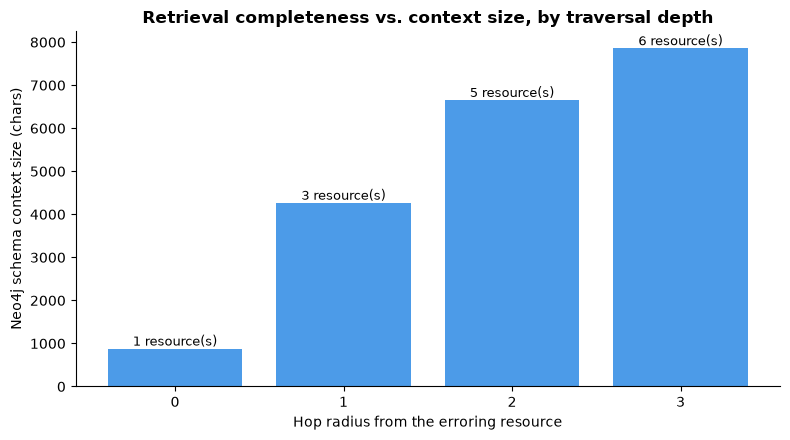

In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hop_df["hop_radius"].astype(str), hop_df["context_chars"], color="#4C9BE8")
for i, row in hop_df.iterrows():
    ax.text(i, row["context_chars"], f"{row['resources_included']} resource(s)",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Hop radius from the erroring resource")
ax.set_ylabel("Neo4j schema context size (chars)")
ax.set_title("Retrieval completeness vs. context size, by traversal depth", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Why the shipped retriever stays at hop 0

`agents/retriever.py`'s `_extract_error_resources()` intentionally returns a flat
set — it scopes Neo4j lookups to exactly the resource(s) an active error names, and
nothing else (see its own docstring: "avoiding full-template schema dumps when only
1-2 resources have active errors"). That is hop-0 in the framing above. The
trade-off this section makes visible: hop-0 is the cheapest and most precise, but a
genuinely cross-resource problem (a `SecurityGroup` misconfiguration that only
matters because of how the `Instance` attaches it, say) might need hop-1 context to
fix correctly. Widening past hop-0 was never implemented in `agents/retriever.py` —
this section is the evidence for whether it would be worth adding, not a preview of
existing behaviour.

## 9 · Full end-to-end run — the unmodified `retriever_agent()`

Everything above called the internal pieces individually for visibility. This final
cell calls `agents.retriever.retriever_agent(state, recorder)` **exactly** as
`main.py`'s LangGraph state machine does — same function, same arguments, no
modification — using the combined state (cfn-lint + trivy + deploy all failing at
once, as a real remediation iteration would present them).

`ResearchRecorder` is the same class the real pipeline uses to persist
`retriever_history.txt`; it's pointed at a demo run directory under `./runs/` so this
notebook doesn't interfere with any real benchmark run's tracking files.

In [41]:
from datetime import datetime

run_id = f"retriever_rag_simulation_{datetime.now():%Y%m%d_%H%M%S}"
recorder = ResearchRecorder(run_id=run_id, output_dir="./runs")

full_state = {
    "iac_type": "cloudformation",
    "iac_template": SAMPLE_TEMPLATE,
    "validation_results": [lint_result, trivy_result],
    "deploy_validation_result": deploy_validation_result,
    "smell_report": None,
    "remediation_history": [],
    "current_iteration": 1,
    "llm_call_log": [],
    "retriever_history": [],
}

try:
    # Genuinely unmodified call — no try/except inside retriever_agent() itself,
    # this wrapper exists only so a stale LLM_CONFIG.model (see note below)
    # doesn't stop the rest of the notebook from being rerunnable.
    result = retriever_agent(full_state, recorder)

    print(f"retriever_queries ({len(result['retriever_queries'])}):")
    for q in result["retriever_queries"]:
        print(f"  - {q}")

    print(f"\nretriever_context ({len(result['retriever_context'])} chars):\n")
    print(result["retriever_context"])

    print(f"\nRun artifacts written under: ./runs/{run_id}/")
except Exception as exc:
    print(f"[retriever_agent] call failed: {exc!r}")
    print(
        "\nThis is a config issue, not a retrieval bug: retriever_agent() has no "
        "try/except around its LLM query-generation call (unlike the instrumented "
        "cells above, which added one purely for this notebook's robustness), so "
        "an invalid/deprecated model in config.DEFAULT_CONFIG.model "
        f"(currently {config.DEFAULT_CONFIG.model!r}) surfaces exactly like this in "
        "a real run too. Fix by pointing config.DEFAULT_CONFIG at a current model, "
        "e.g.:\n"
        "    import dataclasses\n"
        "    config.DEFAULT_CONFIG = dataclasses.replace(config.DEFAULT_CONFIG, model='x-ai/grok-4.1')\n"
        "then re-run this cell."
    )


[Retriever] Building context (iteration 1, iac_type=cloudformation)...
[Retriever] Annotation: 2 resources parsed.
[Retriever] Routing -> Schema: True | Security: True
[Retriever] Line numbers detected — annotated template    included.
[RAG Tool] Parsed 4 schema queries and 0 security queries from LLM response.
[Retriever] seed_resources (2): ['AWS::EC2::Instance', 'AWS::EC2::SecurityGroup']
[Retriever] Error resources scoped to: ['AWS::EC2::Instance', 'AWS::EC2::SecurityGroup']
[RAG Tool] Stage 1: 12 chunks retrieved, 0 dropped (distance > 0.4), 8 filtered (not in template), 4 kept  [mode=compact].
[RAG Tool] Stage 2: Scoped to 2 error/chroma resources (skipping 0 non-erroring resources).
[SecurityRAG] Extracted 2 unique ID(s) from 5 raw error string(s): ['AWS-0028', 'AWS-0131']
[SecurityRAG] Graph lookup: querying Neo4j for 2 check(s) (iac_type=cloudformation, frameworks=['cfn', 'cloudformation'])...
[SecurityRAG] Graph lookup: 2/2 check(s) resolved from Neo4j.
[SecurityRAG] Include

## Summary

| Query | ChromaDB (Ollama embeddings)? | Neo4j? | LLM call? | Neo4j scope |
|---|---|---|---|---|
| Lint error (cfn-lint) | ✅ Stage 1 semantic search | ✅ Stage 2 schema traversal | ✅ query generation | resource(s) named in the cfn-lint `Resource:` marker |
| Trivy error (security) | ❌ (rule ID is already explicit — no ambiguity to resolve) | ✅ `SecurityCheck` traversal | ❌ (deterministic regex ID extraction) | the exact check ID(s), framework-filtered |
| Deploy error | ✅ Stage 1 semantic search | ✅ Stage 2 schema traversal | ✅ query generation | resource(s) named in `deploy_validation_result.failed_resources` |

This asymmetry — schema errors get an LLM-driven hybrid ChromaDB+Neo4j search,
security errors get a purely deterministic Neo4j lookup — is a deliberate design
choice in `agents/retriever.py` (see `tools/security_hybrid_rag.py`'s module
docstring), not a gap. Section 7's unmodified `retriever_agent()` call demonstrates
both paths firing together in a single iteration, exactly as the real LangGraph state
machine would present a mixed-failure remediation step.